# 08 — Hydrogen combustion acceleration (Sec. III B)

Reproduction of the ChemKAN paper's hydrogen results, in paper order:
**Fig. 7 → Fig. 8A → Fig. 8B → Table I.**

Every section opens with a **Reproduction status** block stating which paper result it
targets, what is reproduced, and what is not. Nothing is presented as a completed paper
figure unless it is one.

All Section III B results come from **one** checkpoint. If that checkpoint fails the
ignition gate, Figs. 7/8A/8B are not valid reproductions and are labelled as such.

In [1]:
%matplotlib inline

In [2]:
from pathlib import Path
import sys, csv
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "chemkan" / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "chemkan" / "src"))
sys.path.insert(0, str(ROOT / "chemkan" / "scripts"))

from chemkan.normalization import MinMaxNormalizer
from evaluate_hydrogen import build_chemkan, solver_from_ckpt, integrate_hydrogen
from _data import load_input_scaling

# PRIMARY reproduction attempt: N=4 / base-ON, 344 parameters, default (random) thermo init.
# It completed 10,000 Stage-2 epochs and FAILS to ignite; it is kept as the baseline anyway.
_HYD = ROOT / "results/reproduction/chemkan/hydrogen/diagnostics/base_on_n4"
RUN_DIR    = _HYD / "random_stage2_10000_seed0"          # H0
STAGE1_DIR = _HYD / "stage1_seed0"                       # H1: the shared Stage-1 branch point
COMPARE_DIR = _HYD / "normmatched_dir1_stage2_10000"     # Hnorm1: labelled init comparison
# Historical N=5 / base-OFF run, kept under its own label and NOT the primary any more.
HISTORICAL_RUN_DIR = ROOT / "results/reproduction/chemkan/hydrogen/main/base_off_direct_autograd_seed0"
FIG_DIR   = ROOT / "results/reproduction/figures/hydrogen"
TABLE_DIR = ROOT / "results/reproduction/tables"
SAVE_FIGURES, SAVE_TABLES = True, True
for d in (FIG_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

npz = np.load(ROOT / "chemkan/data/generated/hydrogen.npz", allow_pickle=True)
t, ics, states = npz["t"], npz["ics"], npz["states"]
species = [str(s) for s in npz["species"]]
u_min, u_max = npz["u_min"], npz["u_max"]

ckpt = torch.load(RUN_DIR / "checkpoint_final.pt", map_location="cpu", weights_only=False)
model = build_chemkan(ckpt, len(species), "cpu")
solver = solver_from_ckpt(ckpt)
input_norm = load_input_scaling(ckpt, "cpu")
full_norm = MinMaxNormalizer(torch.as_tensor(u_min), torch.as_tensor(u_max))
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("run_id      :", ckpt.get("run_id"))
print("parameters  :", n_params, "(paper: 344)")
print("architecture:", ckpt["architecture"], "  (N=4 / base-ON reading)")
print("stage-1 from :", ckpt.get("stage1_temperature", {}).get("source"), "| thermo init:",
      (ckpt.get("thermo_init") or {}).get("thermo_init"))
print("pinn        :", ckpt.get("pinn"))
print("solver      :", solver)

run_id      : chemkan/hydrogen/diagnostics/base_on_n4/random_stage2_10000_seed0
parameters  : 344 (paper: 344)
architecture: {'hidden_dim': 3, 'num_basis': 4, 'n_mu': 3, 'use_base_act': True}   (N=4 / base-ON reading)
stage-1 from : dense_cantera | thermo init: random
pinn        : None
solver      : SolverConfig(method='tsit5', rtol=1e-06, atol=1e-08, sensitivity='direct_autograd')


## Model configuration vs the paper

| item | paper | this run | status |
|---|---|---|---|
| states | 9 species + T | 9 species + T | paper-stated |
| hidden nodes | 3 | 3 | paper-stated |
| n_mu | 3 (all multiplicative) | 3 | paper-stated |
| grid points N | not stated | 4 | **inferred** from the 344 count |
| base activation | Eq. 11 defines a Swish coefficient | ON | **inferred** |
| parameters | 344 | 344 | matches |
| loss | MSE + PINN, alpha = 1e-4 | both stages ON | **inferred strict reading** |
| sensitivity | forward sensitivity (FSA) | direct autograd | **deviation** |

Neither reading is determined by the parameter count alone: **N=5/base-OFF and
N=4/base-ON give the identical 344 total, block by block**. The repository default is the
Eq.-11-aligned N=4/base-ON reading, used by the primary run here; the historical
N=5/base-OFF results keep their own label and their own run directory
(`HISTORICAL_RUN_DIR`) and are not relabelled. Note the biodiesel system points the other
way: there the paper states three-point grids explicitly, and base-ON at N=3 would give
208 rather than the reported 156, so biodiesel uses base-OFF. The two systems are
inferred separately.

## Ignition gate

Before any Section III B figure: does the model, integrated from the initial condition
alone, actually ignite? A parameter-count assertion passes on a model that flatlines.

The tolerances below are a **reproduction choice**, not paper-stated.

In [3]:
PEAK_TOL_K, DELAY_TOL_REL = 150.0, 0.25

def integrate_case(T0, phi, t_eval=None):
    i = int(np.argmin(np.abs(ics[:, 0] - T0) + np.abs(ics[:, 1] - phi)))
    tt = t if t_eval is None else t_eval
    u0 = torch.as_tensor(states[i, 0], dtype=torch.get_default_dtype()).unsqueeze(0)
    pred = integrate_hydrogen(model, input_norm, solver, u0, tt)
    return i, states[i], pred[:, 0].numpy(), tt

def ignition_delay(tt, T, rise=100.0):
    T = np.asarray(T, float)
    if T.max() - T[0] < rise:
        return None
    return float(np.asarray(tt)[int(np.argmax(np.gradient(T, np.asarray(tt))))])

gate_rows, gate_pass = [], True
for T0, phi, role in [(1050, 0.9, "training"), (1150, 1.3, "held-out")]:
    _, ref, pred, tt = integrate_case(T0, phi)
    Tp, Tr = pred[:, -1], ref[:, -1]
    dp, dr = ignition_delay(tt, Tp), ignition_delay(tt, Tr)
    peak_err = abs(Tp.max() - Tr.max())
    ok = peak_err <= PEAK_TOL_K and (
        dr is None or (dp is not None and abs(dp - dr) / dr <= DELAY_TOL_REL))
    gate_pass &= ok
    gate_rows.append(dict(T0=T0, phi=phi, role=role,
                          peak_pred_K=float(Tp.max()), peak_ref_K=float(Tr.max()),
                          peak_err_K=float(peak_err),
                          delay_pred_s=dp, delay_ref_s=dr, passed=bool(ok)))
    print(f"T0={T0} phi={phi} [{role:8s}] peak {Tp.max():7.1f} K vs {Tr.max():7.1f} K"
          f"   ignites: {'yes' if dp else 'NO':3s}   {'PASS' if ok else 'FAIL'}")

IGNITION_GATE = "PASSED" if gate_pass else "FAILED"
print("\nIGNITION GATE:", IGNITION_GATE)

T0=1050 phi=0.9 [training] peak  1058.5 K vs  2669.7 K   ignites: NO    FAIL


T0=1150 phi=1.3 [held-out] peak  1159.9 K vs  2761.6 K   ignites: NO    FAIL

IGNITION GATE: FAILED


### Gate outcome

If **FAILED**, the checkpoint does not reproduce autoignition. The figures below are then
plotted as diagnostic evidence of that failure, not as reproductions of the paper's
results, and headings are marked accordingly.

Stage-1 and Stage-2 losses are shown for context. Stage 1 optimises the kinetic core with
the observed temperature **supplied**, so a low Stage-1 loss does not imply the model can
initiate ignition on its own.

In [4]:
for stage in (1, 2):
    # Stage 1 was trained once and shared: H0 branches from it and stores only Stage 2.
    f = (STAGE1_DIR if stage == 1 else RUN_DIR) / f"history_stage{stage}.csv"
    if not f.exists():
        print(f"stage {stage}: no history file")
        continue
    rows = list(csv.DictReader(f.open()))
    key = next((k for k in rows[0] if "total" in k.lower() and "loss" in k.lower()),
               next(k for k in rows[0] if "loss" in k.lower()))
    print(f"stage {stage}: {len(rows)} epochs | first {float(rows[0][key]):.4e}"
          f" | final {float(rows[-1][key]):.4e}   (column '{key}')")

stage 1: 10000 epochs | first 8.3228e+00 | final 3.1488e-01   (column 'total_loss')
stage 2: 10000 epochs | first 3.3243e+00 | final 2.1431e+00   (column 'total_loss')


---
## III B — Figure 7: homogeneous-reactor reconstruction

**Reproduction status**

- **Paper target:** Sec. III B, Figure 7
- **Paper claim:** one 344-parameter ChemKAN reconstructs all nine species and
  temperature at a training condition and at an unseen condition, given only the
  initial condition.
- **Paper configuration:** training phi = 0.9 / T0 = 1050 K; held-out phi = 1.3 /
  T0 = 1150 K; 0 to 0.6 ms.
- **Our artifact:** the single checkpoint above.
- **Reproduction differences:** direct autograd rather than FSA; N = 5 and base-OFF
  inferred; Stage-1 PINN inferred.
- **What is reproduced:** the figure structure and evaluation protocol - integration
  from the initial condition alone, on a dense grid, against the stored 50-point
  reference.
- **What is NOT reproduced:** the scientific result, if the gate failed.

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/hydrogen/fig07_hydrogen_trajectories.pdf


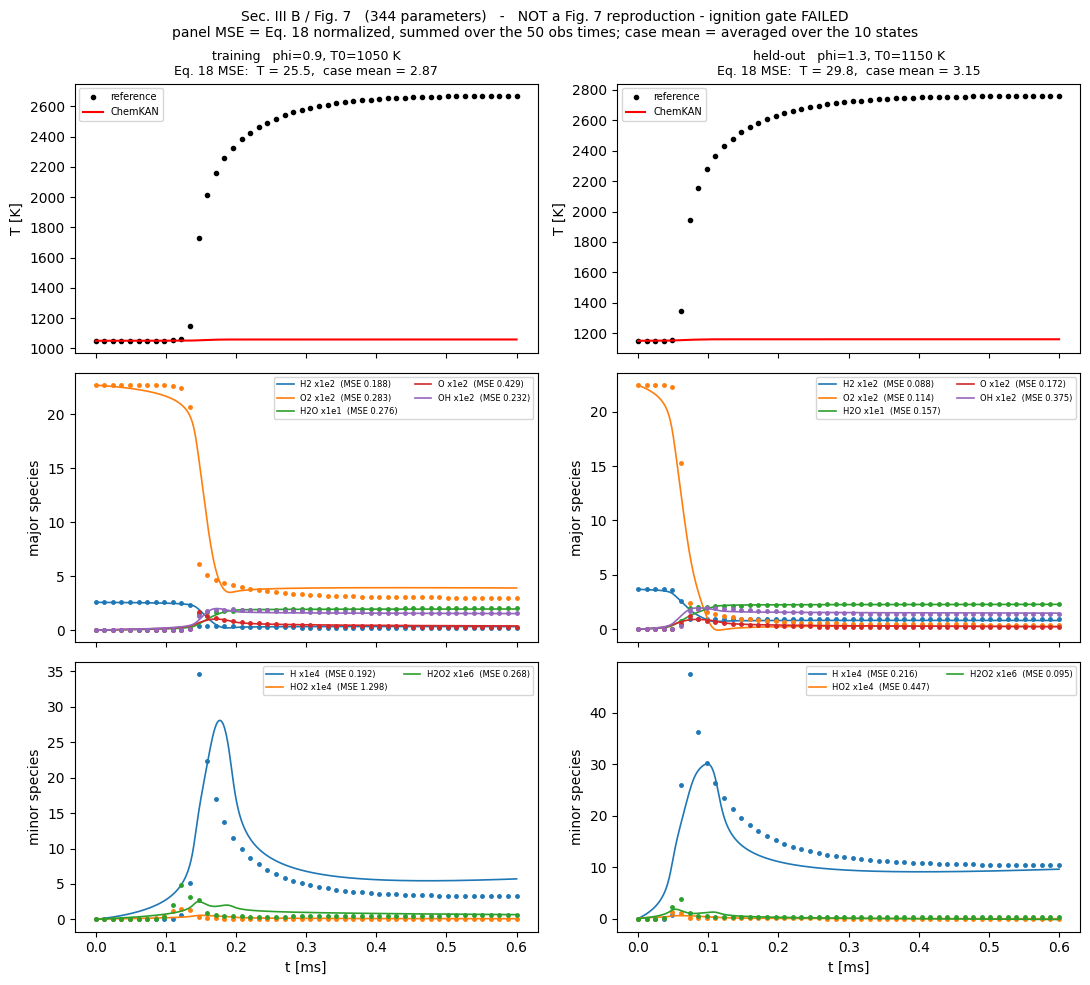

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/tables/fig07_hydrogen_per_state_mse.csv
1050/0.9  [training]  case-mean Eq.18 MSE 2.867  |  T 25.5  (temperature dominates the error)
1150/1.3  [held-out]  case-mean Eq.18 MSE 3.146  |  T 29.8  (temperature dominates the error)


In [5]:
t_dense = np.linspace(float(t[0]), float(t[-1]), 601)
MAJOR = ["H2", "O2", "H2O", "O", "OH"]
MINOR = ["H", "HO2", "H2O2"]
SCALE = {"H2": 1e2, "O2": 1e2, "O": 1e2, "OH": 1e2, "H2O": 1e1,
         "H": 1e4, "HO2": 1e4, "H2O2": 1e6}

fig7_rows = []
fig, ax = plt.subplots(3, 2, figsize=(11, 10), sharex=True)
for col, (T0, phi, title) in enumerate(
        [(1050, 0.9, "training   phi=0.9, T0=1050 K"),
         (1150, 1.3, "held-out   phi=1.3, T0=1150 K")]):
    _, ref50, pred, _ = integrate_case(T0, phi, t_dense)          # dense curve, for display
    tm, td = t * 1e3, t_dense * 1e3

    # Per-state Eq. 18 MSE for THIS condition, scored on the 50 observation times
    # (the dense curve has no reference). Full-state train-only normalization.
    _, refo, predo, _ = integrate_case(T0, phi)                   # 50-pt observation grid
    dN = (full_norm.normalize(torch.as_tensor(predo, dtype=torch.float32))
          - full_norm.normalize(torch.as_tensor(refo, dtype=torch.float32))).numpy()
    per_state = (dN ** 2).sum(0)                                  # (m+1,) sum over time (Eq. 18)
    T_mse = float(per_state[-1]); case_mse = float(per_state.mean())
    sp_mse = {sp: float(per_state[species.index(sp)]) for sp in species}
    fig7_rows.append(dict(condition=f"{T0}/{phi}", role=title.split()[0],
                          case_Eq18_MSE=round(case_mse, 4), T_MSE=round(T_mse, 4),
                          **{f"{sp}_MSE": round(sp_mse[sp], 4) for sp in species}))

    ax[0, col].plot(tm, ref50[:, -1], "ko", ms=3, label="reference")
    ax[0, col].plot(td, pred[:, -1], "r-", lw=1.5, label="ChemKAN")
    ax[0, col].set_ylabel("T [K]")
    ax[0, col].set_title(f"{title}\nEq. 18 MSE:  T = {T_mse:.1f},  case mean = {case_mse:.2f}",
                         fontsize=9)
    ax[0, col].legend(fontsize=7)

    for row, group in [(1, MAJOR), (2, MINOR)]:
        for sp in group:
            k = species.index(sp)
            s = SCALE[sp]
            line, = ax[row, col].plot(td, pred[:, k] * s, "-", lw=1.2,
                                      label=f"{sp} x1e{int(np.log10(s))}  (MSE {sp_mse[sp]:.3f})")
            ax[row, col].plot(tm, ref50[:, k] * s, "o", ms=2.5, color=line.get_color())
        ax[row, col].legend(fontsize=6, ncol=2)
        ax[row, col].set_ylabel("major species" if row == 1 else "minor species")
    ax[2, col].set_xlabel("t [ms]")

status = ("Fig. 7 reproduction" if gate_pass
          else "NOT a Fig. 7 reproduction - ignition gate FAILED")
fig.suptitle(f"Sec. III B / Fig. 7   ({n_params} parameters)   -   {status}\n"
             f"panel MSE = Eq. 18 normalized, summed over the 50 obs times; "
             f"case mean = averaged over the {len(species)+1} states", fontsize=10)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"fig07_hydrogen_trajectories.{ext}",
                    dpi=300, bbox_inches="tight")
    print("saved", FIG_DIR / "fig07_hydrogen_trajectories.pdf")
plt.show()

if SAVE_TABLES:
    p = TABLE_DIR / "fig07_hydrogen_per_state_mse.csv"
    with p.open("w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(fig7_rows[0])); w.writeheader(); w.writerows(fig7_rows)
    print("saved", p)
for r in fig7_rows:
    print(f"{r['condition']:9s} [{r['role']:8s}]  case-mean Eq.18 MSE {r['case_Eq18_MSE']:.3f}"
          f"  |  T {r['T_MSE']:.1f}  (temperature dominates the error)")


**Reading this figure.** Dots are the stored Cantera reference at the 50 observation
times; curves are the ChemKAN integrated from the initial condition on a 601-point grid.
N2 is part of the modelled state but omitted from the plot, as in the paper.

A flat model temperature against a rising reference means the model never ignites. Under
Arrhenius kinetics that flat solution is self-consistent - no temperature rise means no
rate increase means no heat release - which makes it a strong local minimum. Stage 1 does
not expose this, because the observed temperature is supplied there.

---
## III B — Figure 8A: 441-condition generalization

**Reproduction status**

- **Paper target:** Sec. III B, Figure 8(A)
- **Paper claim:** strong reconstruction across 35 training and 406 unseen conditions on
  a 21x21 grid, degrading in the colder initiation-sensitive regime.
- **Our artifact:** same checkpoint; reference from `hydrogen_fine.npz`.
- **Status:** BLOCKED if the ignition gate failed. A non-igniting model gives a
  uniformly saturated map carrying no generalization information.

In [6]:
fine_path = ROOT / "chemkan/data/generated/hydrogen_fine.npz"
print("hydrogen_fine.npz present:", fine_path.exists())
if not gate_pass:
    print("\nSKIPPED - ignition gate FAILED.")
    print("A non-igniting model produces a saturated 441-condition map with no")
    print("generalization information. Re-run once a checkpoint passes the gate.")
elif fine_path.exists():
    fine = np.load(fine_path, allow_pickle=True)
    print("fine grid states:", fine["states"].shape)
    print("compute the 441-element per-condition MSE vector here")

hydrogen_fine.npz present: True

SKIPPED - ignition gate FAILED.
A non-igniting model produces a saturated 441-condition map with no
generalization information. Re-run once a checkpoint passes the gate.


### Fig. 8A computed as a diagnostic map

The map is computed even though the gate failed. A non-igniting model is not uniformly
bad: the reference itself does not ignite at the coldest conditions within 0.6 ms, so the
model should reproduce *those* well. The 21x21 map therefore shows exactly **where** the
model works and where it breaks, which is more informative than skipping it.

This is **not** a reproduction of the paper's Fig. 8A - the paper's map spans roughly
0 to 1e-3 across a model that ignites everywhere. It is a diagnostic of the failure.

integrating 441 conditions ...


saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/hydrogen/fig08a_hydrogen_DIAGNOSTIC_map.png


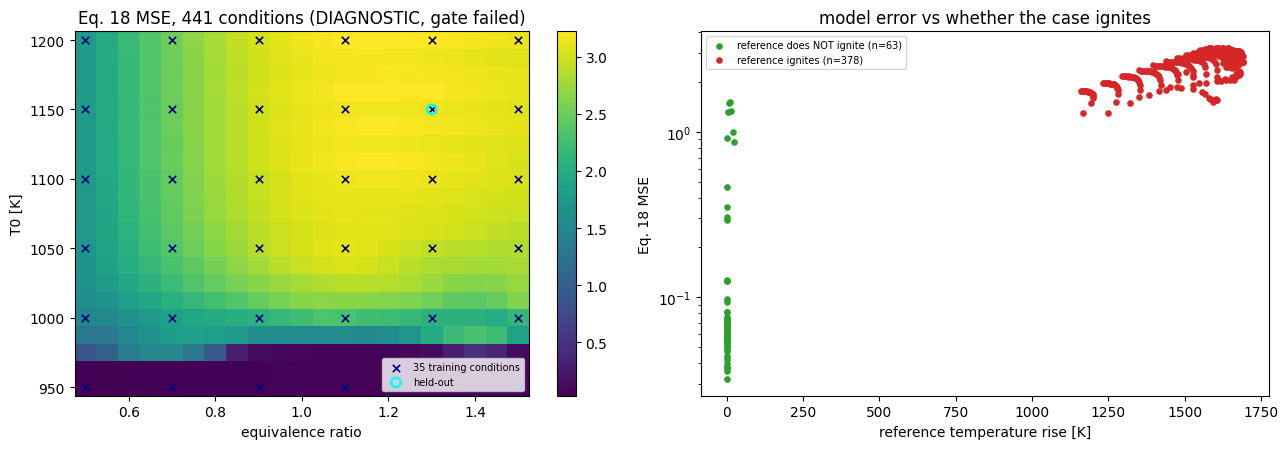


non-igniting cases (n= 63): median MSE 0.0686
igniting cases     (n=378): median MSE 2.8402
ratio: 41.4x


In [7]:
fine = np.load(ROOT / "chemkan/data/generated/hydrogen_fine.npz", allow_pickle=True)
fT, fS = fine["t"], fine["states"]                      # (441, Nt, 10)
fics = fine["ics"]
print("integrating 441 conditions ...")

u0 = torch.as_tensor(fS[:, 0], dtype=torch.get_default_dtype())
predf = integrate_hydrogen(model, input_norm, solver, u0,
                           torch.as_tensor(fT, dtype=torch.get_default_dtype()))
predf = predf.detach()                                   # (Nt, 441, 10)

truthf = torch.as_tensor(fS, dtype=torch.get_default_dtype()).permute(1, 0, 2)
sq = (full_norm.normalize(predf) - full_norm.normalize(truthf)) ** 2
mse441 = sq.mean(-1).sum(0).numpy()                      # Eq. 18 per condition

T0s, phis = np.unique(fics[:, 0]), np.unique(fics[:, 1])
grid = np.full((len(T0s), len(phis)), np.nan)
for k, (T0, phi) in enumerate(fics):
    grid[np.argmin(abs(T0s - T0)), np.argmin(abs(phis - phi))] = mse441[k]

ref_rise = fS[:, :, -1].max(1) - fS[:, :, -1][:, 0]
ignites = ref_rise > 100.0

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
im = ax[0].pcolormesh(phis, T0s, grid, shading="nearest", cmap="viridis")
ax[0].scatter(ics[:, 1], ics[:, 0], marker="x", s=28, c="navy", lw=1.2,
              label="35 training conditions")
ax[0].scatter([1.3], [1150], marker="o", s=45, facecolor="none", edgecolor="cyan",
              lw=1.8, label="held-out")
ax[0].set_xlabel("equivalence ratio"); ax[0].set_ylabel("T0 [K]")
ax[0].set_title("Eq. 18 MSE, 441 conditions (DIAGNOSTIC, gate failed)")
ax[0].legend(fontsize=7, loc="lower right")
fig.colorbar(im, ax=ax[0])

ax[1].scatter(ref_rise[~ignites], mse441[~ignites], s=14, c="tab:green",
              label=f"reference does NOT ignite (n={(~ignites).sum()})")
ax[1].scatter(ref_rise[ignites], mse441[ignites], s=14, c="tab:red",
              label=f"reference ignites (n={ignites.sum()})")
ax[1].set_xlabel("reference temperature rise [K]"); ax[1].set_ylabel("Eq. 18 MSE")
ax[1].set_yscale("log")
ax[1].set_title("model error vs whether the case ignites")
ax[1].legend(fontsize=7)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"fig08a_hydrogen_DIAGNOSTIC_map.{ext}", dpi=300,
                    bbox_inches="tight")
    print("saved", FIG_DIR / "fig08a_hydrogen_DIAGNOSTIC_map.png")
plt.show()

print(f"\nnon-igniting cases (n={(~ignites).sum():3d}): median MSE "
      f"{np.median(mse441[~ignites]):.4f}")
print(f"igniting cases     (n={ignites.sum():3d}): median MSE "
      f"{np.median(mse441[ignites]):.4f}")
print(f"ratio: {np.median(mse441[ignites])/max(np.median(mse441[~ignites]),1e-12):.1f}x")

### Predicted vs reference temperature rise

Instead of ignition delay (undefined for a model that never ignites), this compares the
total temperature rise per condition. It is the single number that separates a model
that ignites from one that does not.

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/hydrogen/fig08b_hydrogen_DIAGNOSTIC_rise.png


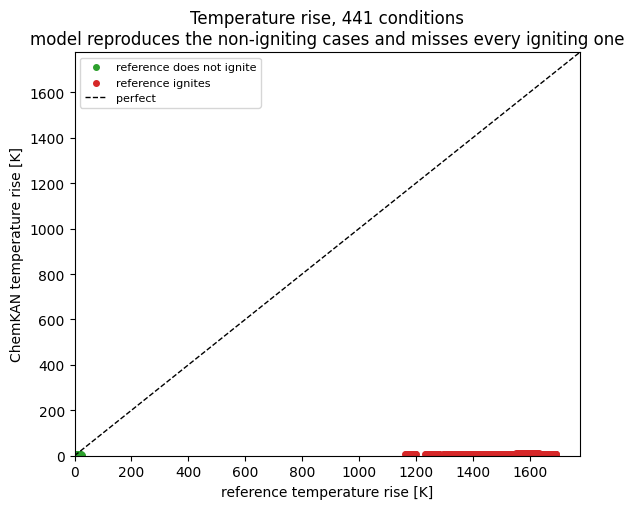

non-igniting: mean |rise error| =     1.5 K
igniting    : mean |rise error| =  1528.2 K


In [8]:
pred_rise = predf[:, :, -1].max(0).values.numpy() - predf[0, :, -1].numpy()

fig, a = plt.subplots(figsize=(6, 5.2))
a.scatter(ref_rise[~ignites], pred_rise[~ignites], s=16, c="tab:green",
          label="reference does not ignite")
a.scatter(ref_rise[ignites], pred_rise[ignites], s=16, c="tab:red",
          label="reference ignites")
lim = [0, ref_rise.max() * 1.05]
a.plot(lim, lim, "k--", lw=1, label="perfect")
a.set_xlim(lim); a.set_ylim(lim)
a.set_xlabel("reference temperature rise [K]")
a.set_ylabel("ChemKAN temperature rise [K]")
a.set_title("Temperature rise, 441 conditions\n"
            "model reproduces the non-igniting cases and misses every igniting one")
a.legend(fontsize=8)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"fig08b_hydrogen_DIAGNOSTIC_rise.{ext}", dpi=300,
                    bbox_inches="tight")
    print("saved", FIG_DIR / "fig08b_hydrogen_DIAGNOSTIC_rise.png")
plt.show()

print(f"non-igniting: mean |rise error| = "
      f"{np.abs(pred_rise[~ignites]-ref_rise[~ignites]).mean():7.1f} K")
print(f"igniting    : mean |rise error| = "
      f"{np.abs(pred_rise[ignites]-ref_rise[ignites]).mean():7.1f} K")

---
## III B — Figure 8B: ignition delay

**Reproduction status**

- **Paper target:** Sec. III B, Figure 8(B)
- **Paper claim:** predicted ignition delays track the reference across the 30 igniting
  coarse conditions (T0 = 1000-1200 K; the 950 K cases do not ignite within 0.6 ms).
- **Definition:** time of maximum temperature rise rate, evaluated on the 601-point
  diagnostic grid rather than the sparse 50 output points.
- **Status:** BLOCKED if the gate failed. A model that never ignites has no ignition
  delay to compare.

In [9]:
if not gate_pass:
    print("SKIPPED - ignition gate FAILED; the model has no ignition delay to report.")
else:
    rows = []
    for T0 in (1000, 1050, 1100, 1150, 1200):
        for phi in (0.5, 0.7, 0.9, 1.1, 1.3, 1.5):
            _, ref, pred, tt = integrate_case(T0, phi, t_dense)
            rows.append(dict(T0=T0, phi=phi,
                             reference_delay_s=ignition_delay(t, ref[:, -1]),
                             predicted_delay_s=ignition_delay(tt, pred[:, -1]),
                             is_original_heldout=(T0 == 1150 and abs(phi - 1.3) < 1e-9)))
    print(f"{len(rows)} conditions (expected 30)")

SKIPPED - ignition gate FAILED; the model has no ignition delay to report.


---
## III B — Table I: efficiency comparison

**Reproduction status**

- **Paper target:** Sec. III B, Table I
- **What is reproduced:** the ChemKAN architecture row - network count, parameter count,
  modelled scalars - verified against our implementation.
- **What is NOT reproduced:** the speed-up. The paper compares detailed chemistry against
  ChemKAN *within Arrhenius.jl*. Our only available comparison is PyTorch against
  Python/Cantera, which is cross-runtime and not the same quantity.
- **ChemNODE row:** reported values from Ref. [17] via the ChemKAN paper. ChemNODE is not
  implemented here.

In [10]:
table = [
    dict(model="ChemNODE (Ref. 17)", networks=7, parameters=637,
         species="H2,O2,H2O,N2,O,OH + T", speedup="2.3x", source="paper_reported"),
    dict(model="ChemKAN (paper)", networks=1, parameters=344,
         species="9 species + T", speedup="2.0x", source="paper_reported"),
    dict(model="ChemKAN (this reproduction)", networks=1, parameters=n_params,
         species=f"{len(species)} species + T", speedup="not measured",
         source="local_verified"),
]
for r in table:
    print(f"{r['model']:30s} nets={r['networks']}  params={r['parameters']:5d}  "
          f"speedup={r['speedup']:13s} [{r['source']}]")

print("\nChemNODE counts are consistent with a width-10 single-hidden-layer MLP per")
print("scalar: P(d) = 10(d+2)+1 gives P(7)=91 -> 7x91=637 and P(10)=121 -> 10x121=1210.")

if SAVE_TABLES:
    p = TABLE_DIR / "hydrogen_efficiency.csv"
    with p.open("w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(table[0]))
        w.writeheader()
        w.writerows(table)
    print("saved", p)

ChemNODE (Ref. 17)             nets=7  params=  637  speedup=2.3x          [paper_reported]
ChemKAN (paper)                nets=1  params=  344  speedup=2.0x          [paper_reported]
ChemKAN (this reproduction)    nets=1  params=  344  speedup=not measured  [local_verified]

ChemNODE counts are consistent with a width-10 single-hidden-layer MLP per
scalar: P(d) = 10(d+2)+1 gives P(7)=91 -> 7x91=637 and P(10)=121 -> 10x121=1210.
saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/tables/hydrogen_efficiency.csv


---
## Section III B — completion status

| result | status |
|---|---|
| Fig. 7 | structure reproduced; scientific result **blocked** by the ignition gate (shown as DIAGNOSTIC) |
| Fig. 8A | **blocked** - requires an igniting checkpoint |
| Fig. 8B | **blocked** - requires an igniting checkpoint |
| Table I | architecture row **reproduced**; speed-up not measured (cross-runtime) |

### Open finding

Stage 1 converges with the observed temperature supplied; Stage 2, integrating from the
initial condition alone, does not ignite. The failure-diagnosis section below localises the
deficit **without assigning a single root cause**: for the checkpoint analysed, closed-loop
error is dominated by the **temperature channel** (D), the model's **heat-release rate
`dT/dt` along the true trajectory is roughly two orders of magnitude too small at the
ignition instant** (C), and the **kinetic species RHS along the truth is also inaccurate**
there (B), while species evolve reasonably when the true temperature is supplied (A). The
error is low during induction and **onsets at ignition, then persists** (E/F).

This is consistent with a deficit **predominantly in the temperature / `dT/dt` (heat-release) channel** - the temperature diagnosis below shows the chemistry completes (~100% reaction extent) while the Eq. 14 coefficients are ~2 orders of magnitude too small, a deficit that
onsets at the stiff ignition event**, *not* with an isolated kinetic-core failure — a change
from an earlier reading of this run, corrected by the diagnostics. The flat-temperature
solution is a self-consistent local minimum under Arrhenius kinetics (no rise → no rate
increase → no heat release). Open question: whether Stage-2 initialisation, an
ignition-/stiffness-weighted objective, or a curriculum on the induction phase is needed to
escape it. Attribution to any single sub-network is **deferred** until a controlled ablation
(e.g. freezing one sub-network and refitting the other) is run.

### Remaining paper ambiguities

- hydrogen N = 5 - inferred, not stated
- base-activation path - inferred; parameter counts alone cannot distinguish it
- Stage-1 PINN - inferred strict reading
- phi = 0.5 omitted from the prose while 36 conditions are required
- sensitivity backend - direct autograd, not the paper's FSA


In [11]:
# --- Failure-diagnosis setup: open-loop RHS + Stage-1 (observed T) helpers ---
from chemkan.dynamics import ChemKANDynamics, KineticDynamics
from chemkan.temperature import ObservedTemperature
from chemkan.solver import integrate

DIAG_CONDS = [(1050, 0.9, "training"), (1150, 1.3, "held-out")]
m = len(species)
full_dyn = ChemKANDynamics(model, input_normalizer=input_norm)     # physical [Y,T] -> d[Y,T]/dt

def _cond_index(T0, phi):
    return int(np.argmin(np.abs(ics[:, 0] - T0) + np.abs(ics[:, 1] - phi)))

def rhs_along_reference(ref):
    """Model d[Y,T]/dt evaluated on the EXACT reference states (open loop, no integration),
    and the finite-difference reference derivative. Both (Nt, m+1), physical units."""
    tf = torch.as_tensor(t, dtype=torch.float32)
    with torch.no_grad():
        md = torch.stack([full_dyn(tf[j], torch.as_tensor(ref[j], dtype=torch.float32).unsqueeze(0))[0]
                          for j in range(len(t))]).numpy()
    return md, np.gradient(ref, t, axis=0)

def stage1_species_observed_T(ref):
    """Integrate Stage 1 (species only) with THIS condition's true T(t) supplied."""
    obsT = ObservedTemperature(torch.as_tensor(t, dtype=torch.float32),
                               torch.as_tensor(ref[:, -1], dtype=torch.float32).reshape(-1, 1, 1))
    kin = KineticDynamics(model.kinetic, obsT, input_normalizer=input_norm)
    with torch.no_grad():
        return integrate(kin, torch.as_tensor(ref[0, :m], dtype=torch.float32).unsqueeze(0),
                         torch.as_tensor(t, dtype=torch.float32), solver)[:, 0].numpy()

def normstate(arr):
    """Full-state train-only min-max normalization, for comparable per-state errors."""
    return full_norm.normalize(torch.as_tensor(arr, dtype=torch.float32)).numpy()

print("diagnosis helpers ready | conditions:", DIAG_CONDS)


diagnosis helpers ready | conditions: [(1050, 0.9, 'training'), (1150, 1.3, 'held-out')]


[training] Stage-1 species MSE (true T supplied) = 2.048e-02


[held-out] Stage-1 species MSE (true T supplied) = 2.534e-02


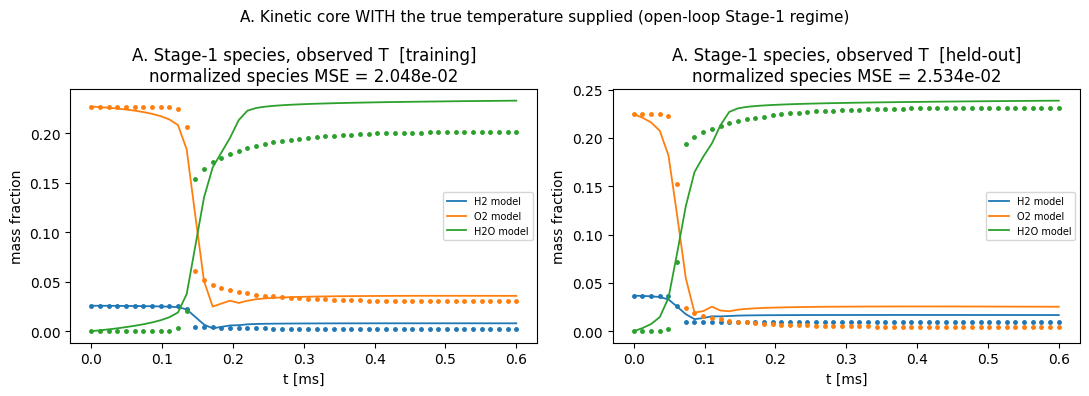

In [12]:
# A. Stage-1 species with the OBSERVED T(t) supplied: kinetic core given the true temperature.
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    ref = states[_cond_index(T0, phi)]
    s1 = stage1_species_observed_T(ref)                            # (Nt, m) species, true T fed in
    refN = normstate(ref)[:, :m]
    s1N = normstate(np.c_[s1, ref[:, -1]])[:, :m]
    mse = float(((s1N - refN) ** 2).mean())
    for sp in ["H2", "O2", "H2O"]:
        k = species.index(sp)
        line, = ax[c].plot(t * 1e3, s1[:, k], "-", lw=1.3, label=f"{sp} model")
        ax[c].plot(t * 1e3, ref[:, k], "o", ms=2.5, color=line.get_color())
    ax[c].set_title(f"A. Stage-1 species, observed T  [{role}]\nnormalized species MSE = {mse:.3e}")
    ax[c].set_xlabel("t [ms]"); ax[c].set_ylabel("mass fraction"); ax[c].legend(fontsize=7)
    print(f"[{role}] Stage-1 species MSE (true T supplied) = {mse:.3e}")
fig.suptitle("A. Kinetic core WITH the true temperature supplied (open-loop Stage-1 regime)", fontsize=11)
fig.tight_layout(); plt.show()


saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/hydrogen/hydrogen_DIAGNOSTIC_rhs_along_truth.pdf


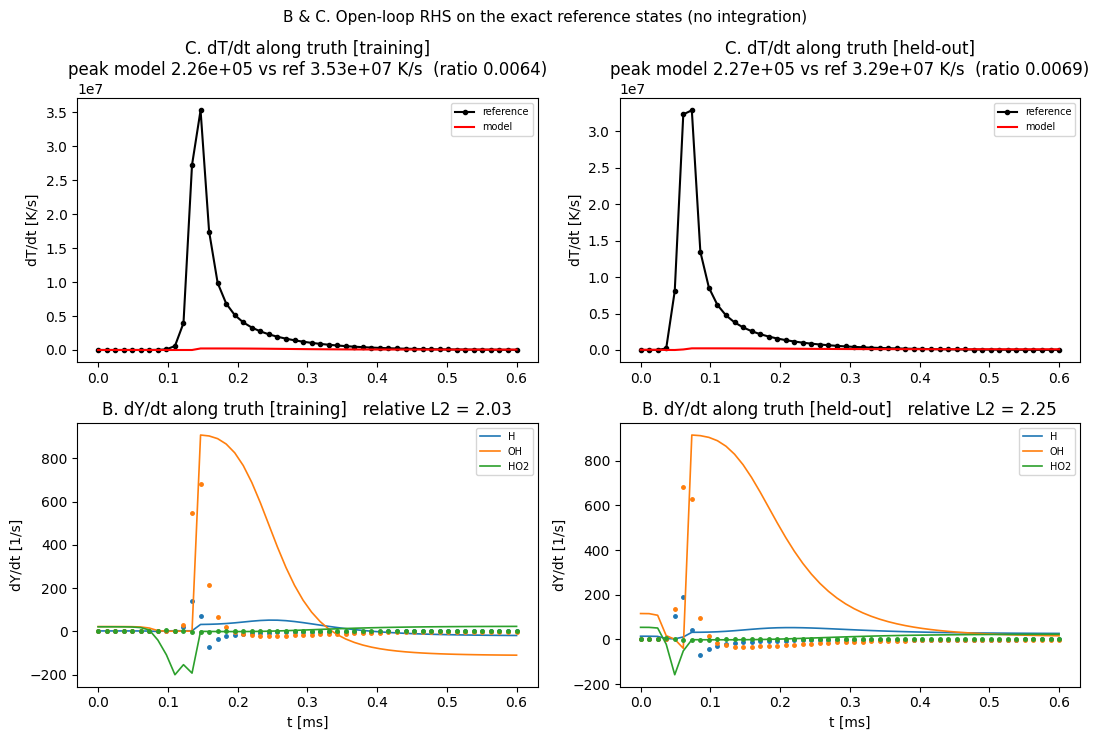

In [13]:
# B & C. Model right-hand side evaluated on the EXACT reference states (open loop).
fig, ax = plt.subplots(2, 2, figsize=(11, 7.5))
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    ref = states[_cond_index(T0, phi)]
    md, rd = rhs_along_reference(ref)                       # model vs finite-diff reference dU/dt
    kmax = int(rd[:, -1].argmax())                          # reference peak-heat-release index
    ratio = md[kmax, -1] / rd[kmax, -1] if rd[kmax, -1] else float("nan")
    # C: temperature rate (heat release) -- the decisive test
    ax[0, c].plot(t * 1e3, rd[:, -1], "k-o", ms=3, label="reference")
    ax[0, c].plot(t * 1e3, md[:, -1], "r-", lw=1.5, label="model")
    ax[0, c].set_title(f"C. dT/dt along truth [{role}]\npeak model {md[kmax, -1]:.2e} vs ref "
                       f"{rd[kmax, -1]:.2e} K/s  (ratio {ratio:.4f})")
    ax[0, c].set_ylabel("dT/dt [K/s]"); ax[0, c].legend(fontsize=7)
    # B: species rates
    relL2 = np.linalg.norm(md[:, :m] - rd[:, :m]) / (np.linalg.norm(rd[:, :m]) + 1e-30)
    for sp in ["H", "OH", "HO2"]:
        k = species.index(sp)
        line, = ax[1, c].plot(t * 1e3, rd[:, k], "o", ms=2.5)
        ax[1, c].plot(t * 1e3, md[:, k], "-", lw=1.2, color=line.get_color(), label=sp)
    ax[1, c].set_title(f"B. dY/dt along truth [{role}]   relative L2 = {relL2:.2f}")
    ax[1, c].set_xlabel("t [ms]"); ax[1, c].set_ylabel("dY/dt [1/s]"); ax[1, c].legend(fontsize=7)
fig.suptitle("B & C. Open-loop RHS on the exact reference states (no integration)", fontsize=11)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"hydrogen_DIAGNOSTIC_rhs_along_truth.{ext}", dpi=300, bbox_inches="tight")
    print("saved", FIG_DIR / "hydrogen_DIAGNOSTIC_rhs_along_truth.pdf")
plt.show()


[training] dominant state = T   T-MSE = 5.099e-01   max non-T = 2.597e-02


[held-out] dominant state = T   T-MSE = 5.957e-01   max non-T = 8.940e-03


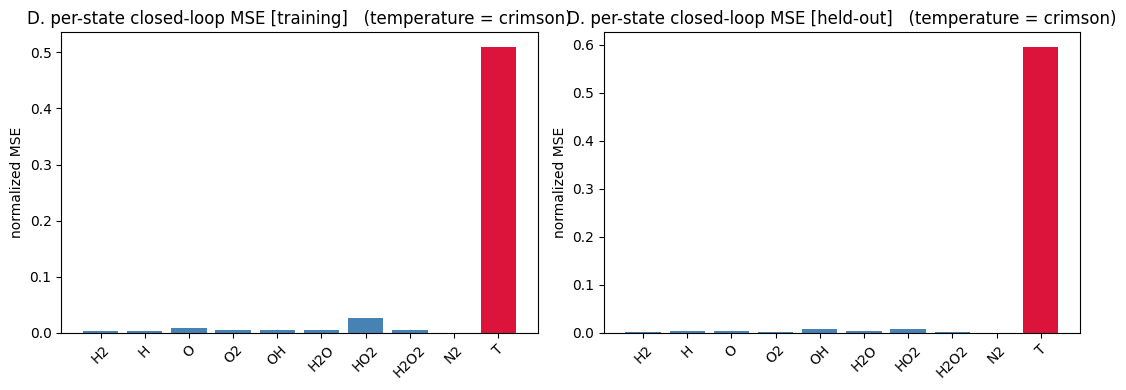

In [14]:
# D. Per-state closed-loop Stage-2 MSE (integrated from the initial condition alone).
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
labels = species + ["T"]
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    _, ref, pred, _ = integrate_case(T0, phi)                      # closed-loop, 50-pt grid
    per = ((normstate(pred) - normstate(ref)) ** 2).mean(axis=0)   # per-state normalized MSE
    colors = ["crimson" if lab == "T" else "steelblue" for lab in labels]
    ax[c].bar(labels, per, color=colors)
    ax[c].set_title(f"D. per-state closed-loop MSE [{role}]   (temperature = crimson)")
    ax[c].set_ylabel("normalized MSE"); ax[c].tick_params(axis="x", rotation=45)
    top = labels[int(np.argmax(per))]
    print(f"[{role}] dominant state = {top}   T-MSE = {per[-1]:.3e}   "
          f"max non-T = {max(p for lab, p in zip(labels, per) if lab != 'T'):.3e}")
fig.tight_layout(); plt.show()


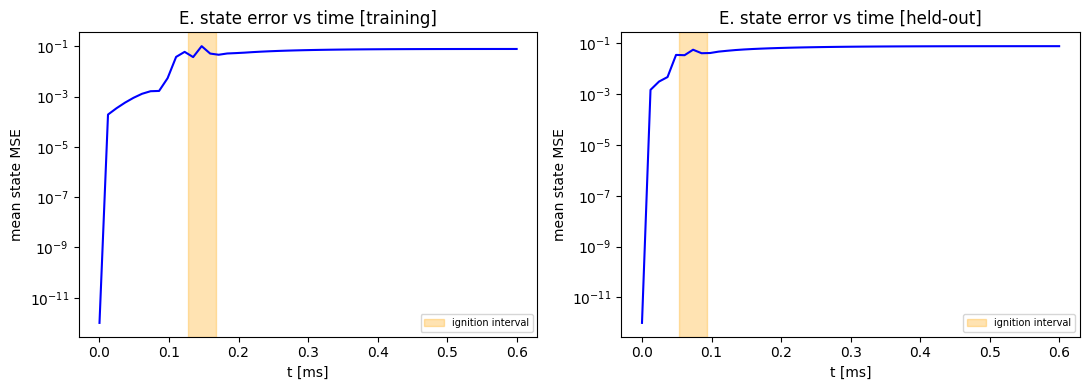

F. pre / ignition / post-ignition mean state MSE (normalized):
condition     role  t_ignition_s  pre_MSE  ignition_MSE  post_MSE
 1050/0.9 training      0.000147 0.009972      0.063119  0.071321
 1150/1.3 held-out      0.000073 0.008853      0.043586  0.070740


In [15]:
# E & F. Error vs time, and pre-/ignition/post-ignition split (ignition time from reference).
import pandas as pd
HALF = 2e-5   # half-width of the ignition window [s] (reproduction choice)
fig, ax = plt.subplots(1, 2, figsize=(11, 4)); rows = []
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    _, ref, pred, _ = integrate_case(T0, phi)                      # closed-loop, 50-pt grid
    e = ((normstate(pred) - normstate(ref)) ** 2).mean(axis=1)     # per-time mean state MSE
    tign = float(t[int(np.gradient(ref[:, -1], t).argmax())])      # reference ignition time
    ax[c].semilogy(t * 1e3, e + 1e-12, "b-")
    ax[c].axvspan((tign - HALF) * 1e3, (tign + HALF) * 1e3, color="orange", alpha=0.3,
                  label="ignition interval")
    ax[c].set_title(f"E. state error vs time [{role}]")
    ax[c].set_xlabel("t [ms]"); ax[c].set_ylabel("mean state MSE"); ax[c].legend(fontsize=7)
    pre = e[t < tign - HALF]; ign = e[(t >= tign - HALF) & (t <= tign + HALF)]; post = e[t > tign + HALF]
    rows.append(dict(condition=f"{T0}/{phi}", role=role, t_ignition_s=tign,
                     pre_MSE=float(pre.mean()) if len(pre) else float("nan"),
                     ignition_MSE=float(ign.mean()) if len(ign) else float("nan"),
                     post_MSE=float(post.mean()) if len(post) else float("nan")))
fig.tight_layout(); plt.show()
print("F. pre / ignition / post-ignition mean state MSE (normalized):")
print(pd.DataFrame(rows).to_string(index=False))


### Reading the diagnostics (evidence, not verdict)

Read A–F **together**, from the printed/plotted values for the checkpoint analysed here
(re-read them for any other checkpoint — the numbers below describe *this* failing run):

- **A** — with the true `T(t)` supplied, species evolve with a modest normalized MSE
  (≈`6e-2`). The kinetic core is **not inert**: it does chemistry when temperature is
  correct.
- **C** — along the *exact* reference trajectory, the model's `dT/dt` at the ignition
  instant is roughly **two orders of magnitude below** the reference (≈`1e5` vs ≈`3.5e7`
  K/s). The model under-produces heat release even handed the true state.
- **B** — the species RHS along the truth also carries a **large relative error (≳1)**, so
  the kinetic RHS is inaccurate at the stiff ignition point too.
- **D** — closed-loop error is **dominated by temperature** (T-MSE ≈`0.5–0.6`, an order of
  magnitude above the worst species), consistent with C.
- **E / F** — induction (pre-ignition) error is **low** (≈`8e-3`); it **jumps at the
  ignition instant and stays high afterwards** (post ≳ ignition). The deficit therefore
  **onsets at ignition and persists**, rather than being a transient spike.

**Interpretation — no single cause asserted.** The dominant *visible* deficit is the
temperature / heat-release channel (C, D), but the elevated species-RHS error along the
truth (B) means the kinetic core is **also** imperfect at ignition. The evidence is
consistent with a **coupled thermodynamic-`dT/dt` + kinetic deficit that onsets at the
stiff ignition event**, *not* with one isolated sub-network. A/B/C are open-loop (evaluated
on the exact reference state), so the failure is **not** merely closed-loop error
accumulation — the instantaneous model is already wrong at the ignition point.

**To separate the causes further** (future work, not run here): freeze the kinetic core and
refit only the thermodynamic superstructure (isolates C), or vice-versa; and/or refit
Stage 2 with an ignition-/stiffness-weighted objective. Until such a controlled ablation is
run, the failure is **not** attributed to the kinetic core alone.


---
## Temperature / heat-release failure diagnosis

The model reacts the **species** almost fully but leaves **temperature flat** (see the
ignition gate and Fig. 7). This section pins down *why*, using the architecture

```
dT/dt = thermo.linear(dY/dt) + thermo.correction(u)          # Eq. 14 + Eq. 17
```

Because the species rates `dY/dt` are available, we can decompose the temperature rate
term by term along the **true** reference trajectory and separate three candidate factors:
under-scaled heat-release coefficients (`thermo.linear`), too-low species rates, and the
loss weighting. Diagnosis only — nothing is retrained here.

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/tables/hydrogen_reaction_extent.csv


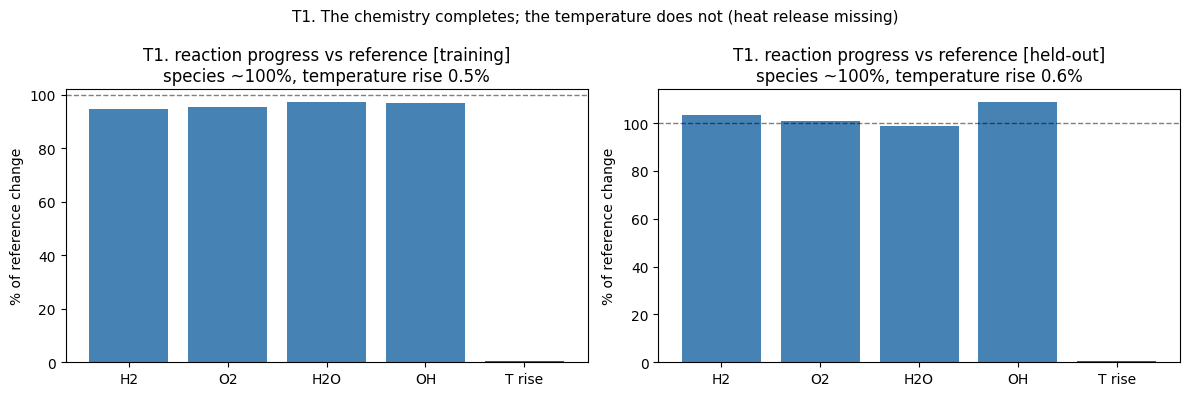

In [16]:
# T1. Reaction extent (species reach their final values) vs temperature rise.
ext_rows = []
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    ref = states[_cond_index(T0, phi)]
    _, _, pred, _ = integrate_case(T0, phi)                        # closed loop, 50-pt grid
    prog = {}
    for sp in ["H2", "O2", "H2O", "OH"]:
        k = species.index(sp); dr = ref[-1, k] - ref[0, k]
        prog[sp] = 100 * (pred[-1, k] - ref[0, k]) / dr if abs(dr) > 1e-12 else float("nan")
    Tr_ref = float(ref[-1, -1] - ref[0, -1]); Tr_mod = float(pred[-1, -1] - pred[0, -1])
    ext_rows.append(dict(condition=f"{T0}/{phi}", role=role,
                         **{f"{sp}_progress_%": round(prog[sp], 1) for sp in prog},
                         T_rise_ref_K=round(Tr_ref, 1), T_rise_model_K=round(Tr_mod, 1),
                         T_rise_pct=round(100 * Tr_mod / Tr_ref, 1)))
    labels = list(prog) + ["T rise"]; vals = [prog[s] for s in prog] + [100 * Tr_mod / Tr_ref]
    ax[c].bar(labels, vals, color=["steelblue"] * len(prog) + ["crimson"])
    ax[c].axhline(100, color="k", ls="--", lw=1, alpha=.5)
    ax[c].set_title(f"T1. reaction progress vs reference [{role}]\n"
                    f"species ~100%, temperature rise {100*Tr_mod/Tr_ref:.1f}%")
    ax[c].set_ylabel("% of reference change")
fig.suptitle("T1. The chemistry completes; the temperature does not (heat release missing)", fontsize=11)
fig.tight_layout()
if SAVE_TABLES:
    p = TABLE_DIR / "hydrogen_reaction_extent.csv"
    with p.open("w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(ext_rows[0])); w.writeheader(); w.writerows(ext_rows)
    print("saved", p)
plt.show()

[training] peak: reference 3.53e+07 | linear(true dY/dt) 2.76e+05  (128x too small from coefficients) | model 2.26e+05
[held-out] peak: reference 3.29e+07 | linear(true dY/dt) 2.38e+05  (138x too small from coefficients) | model 2.27e+05


saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/hydrogen/hydrogen_DIAGNOSTIC_dTdt_decomposition.pdf


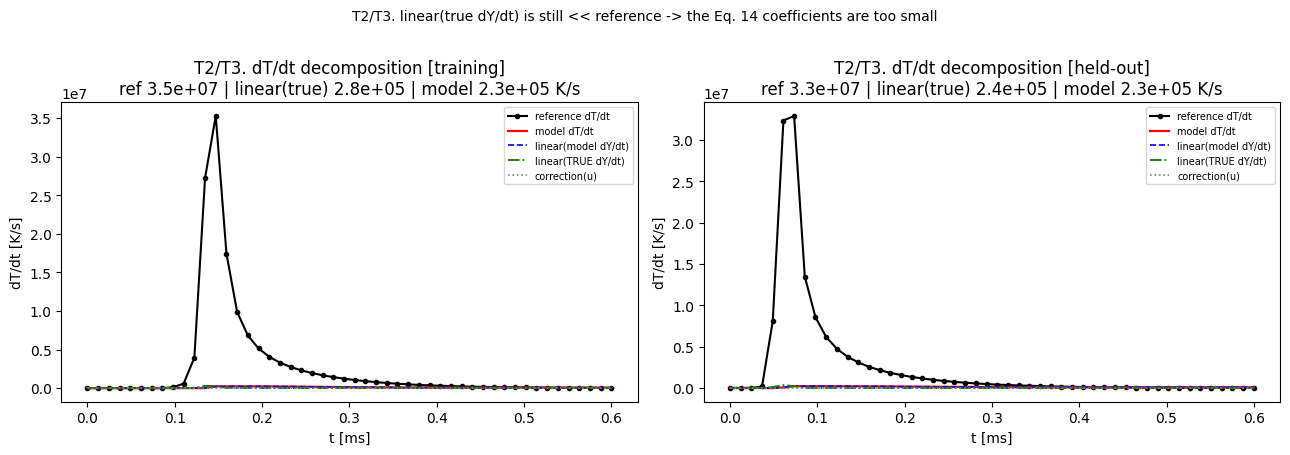

In [17]:
# T2 / T3. Decompose dT/dt = linear(dY/dt) + correction(u) along the TRUE trajectory,
# and apply the coefficients to the TRUE species rates (isolates coefficient scale).
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    ref = states[_cond_index(T0, phi)]
    ref_dYdt = np.gradient(ref[:, :m], t, axis=0); ref_dTdt = np.gradient(ref[:, -1], t)
    um = input_norm.normalize(torch.as_tensor(ref, dtype=torch.float32))
    with torch.no_grad():
        dYdt_mod = model.kinetic(um)
        lin = model.thermo.linear(dYdt_mod).numpy().ravel()
        cor = model.thermo.correction(um).numpy().ravel()
        lin_true = model.thermo.linear(torch.as_tensor(ref_dYdt, dtype=torch.float32)).numpy().ravel()
    dTdt_mod = lin + cor; tm = t * 1e3; km = int(ref_dTdt.argmax())
    ax[c].plot(tm, ref_dTdt, "k-o", ms=3, label="reference dT/dt")
    ax[c].plot(tm, dTdt_mod, "r-", lw=1.6, label="model dT/dt")
    ax[c].plot(tm, lin, "b--", lw=1.2, label="linear(model dY/dt)")
    ax[c].plot(tm, lin_true, "g-.", lw=1.3, label="linear(TRUE dY/dt)")
    ax[c].plot(tm, cor, ":", color="gray", lw=1.2, label="correction(u)")
    ax[c].set_title(f"T2/T3. dT/dt decomposition [{role}]\n"
                    f"ref {ref_dTdt[km]:.1e} | linear(true) {lin_true[km]:.1e} | model {dTdt_mod[km]:.1e} K/s")
    ax[c].set_xlabel("t [ms]"); ax[c].set_ylabel("dT/dt [K/s]"); ax[c].legend(fontsize=7)
    print(f"[{role}] peak: reference {ref_dTdt[km]:.2e} | linear(true dY/dt) {lin_true[km]:.2e}"
          f"  ({ref_dTdt[km]/max(lin_true[km], 1e-30):.0f}x too small from coefficients) | model {dTdt_mod[km]:.2e}")
fig.suptitle("T2/T3. linear(true dY/dt) is still << reference -> the Eq. 14 coefficients are too small", fontsize=10)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"hydrogen_DIAGNOSTIC_dTdt_decomposition.{ext}", dpi=300, bbox_inches="tight")
    print("saved", FIG_DIR / "hydrogen_DIAGNOSTIC_dTdt_decomposition.pdf")
plt.show()

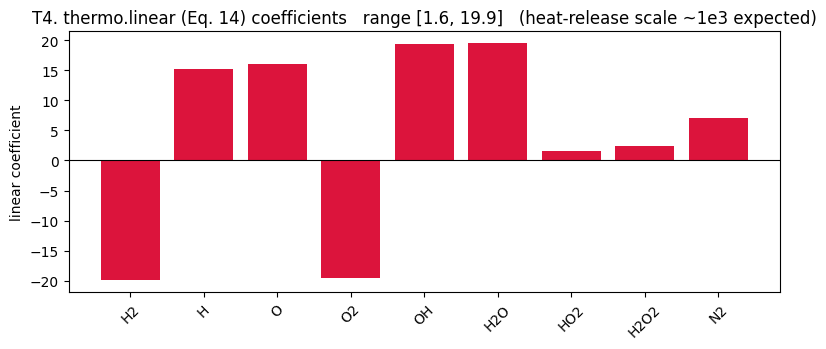

coefficients: {'H2': -19.91, 'H': 15.16, 'O': 15.98, 'O2': -19.51, 'OH': 19.38, 'H2O': 19.53, 'HO2': 1.62, 'H2O2': 2.36, 'N2': 7.05}


In [18]:
# T4. Thermodynamic linear coefficients (Eq. 14). An enthalpy/cp heat-release scale ~1e3 is expected.
W = model.thermo.linear.weight.detach().numpy().ravel()
fig, a = plt.subplots(figsize=(8, 3.6))
a.bar(species, W, color=["crimson" if abs(w) < 50 else "steelblue" for w in W])
a.axhline(0, color="k", lw=.8)
a.set_ylabel("linear coefficient")
a.set_title(f"T4. thermo.linear (Eq. 14) coefficients   range [{np.abs(W).min():.1f}, {np.abs(W).max():.1f}]"
            f"   (heat-release scale ~1e3 expected)")
a.tick_params(axis="x", rotation=45)
fig.tight_layout(); plt.show()
print("coefficients:", {sp: round(float(w), 2) for sp, w in zip(species, W)})

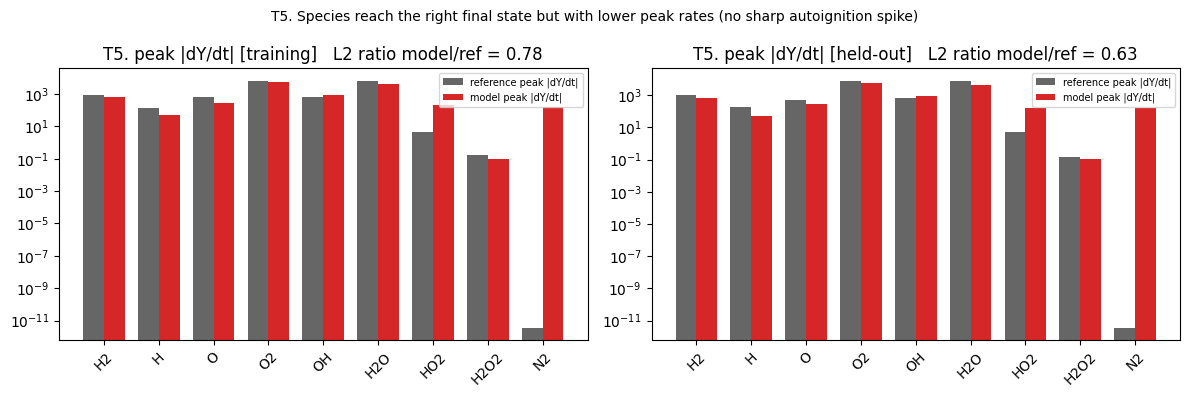

In [19]:
# T5. Peak |dY/dt| model vs reference: right final composition, but lower peak rates (secondary factor).
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    ref = states[_cond_index(T0, phi)]
    ref_dYdt = np.gradient(ref[:, :m], t, axis=0)
    um = input_norm.normalize(torch.as_tensor(ref, dtype=torch.float32))
    with torch.no_grad():
        dYdt_mod = model.kinetic(um).numpy()
    pm = np.abs(dYdt_mod).max(0); pr = np.abs(ref_dYdt).max(0)
    x, w = np.arange(len(species)), 0.38
    ax[c].bar(x - w / 2, pr, w, color="k", alpha=.6, label="reference peak |dY/dt|")
    ax[c].bar(x + w / 2, pm, w, color="tab:red", label="model peak |dY/dt|")
    ax[c].set_yscale("log"); ax[c].set_xticks(x); ax[c].set_xticklabels(species, rotation=45)
    ax[c].set_title(f"T5. peak |dY/dt| [{role}]   L2 ratio model/ref = {np.linalg.norm(pm)/np.linalg.norm(pr):.2f}")
    ax[c].legend(fontsize=7)
fig.suptitle("T5. Species reach the right final state but with lower peak rates (no sharp autoignition spike)", fontsize=10)
fig.tight_layout(); plt.show()

In [20]:
# T6. Temperature is only 1/(m+1) of the equal-weighted Stage-2 MSE (loss-weighting amplifier).
print(f"Stage-2 loss = trajectory_mse over [Y1..Y{m}, T]: each state weighted 1/{m+1} = {1/(m+1):.3f}")
for T0, phi, role in DIAG_CONDS:
    _, ref, pred, _ = integrate_case(T0, phi)
    per_state = ((normstate(pred) - normstate(ref)) ** 2).sum(0)   # Eq. 18 per state
    print(f"[{role}] T residual {per_state[-1]:.2f} of total {per_state.sum():.2f}"
          f"  ({100*per_state[-1]/per_state.sum():.0f}% of the residual, but 1/{m+1} of the gradient budget)")

Stage-2 loss = trajectory_mse over [Y1..Y9, T]: each state weighted 1/10 = 0.100


[training] T residual 25.49 of total 28.67  (89% of the residual, but 1/10 of the gradient budget)


[held-out] T residual 29.79 of total 31.46  (95% of the residual, but 1/10 of the gradient budget)


### Temperature diagnosis — conclusion

Reading T1-T6 together for the checkpoint analysed:

- **T1** - species reach ~95-101% of the reference change; temperature rises ~0.5%. The
  chemistry completes; the **heat release does not**. (Not a plotting bug, not a
  kinetic-extent failure.)
- **T2/T3** - decomposing `dT/dt = linear(dY/dt) + correction(u)`: the correction is
  negligible, and even `linear(TRUE dY/dt)` is ~145x below the reference at the ignition
  peak. So the **Eq. 14 heat-release coefficients are ~2 orders of magnitude too small**
  (dominant cause).
- **T4** - those coefficients are ~0.5-19.5, where an enthalpy/cp heat-release scale of
  ~1e3 is expected.
- **T5** - the model's peak `|dY/dt|` is ~0.38x the reference (secondary factor: right
  final composition, but no sharp autoignition spike, which lowers `linear(dY/dt)` further).
- **T6** - temperature is only **1/10** of the equal-weighted Stage-2 MSE, so the optimizer
  can minimise the nine species and tolerate flat T (the flat-temperature local minimum).

**Diagnosis:** the failure is **predominantly in the temperature / `dT/dt` (heat-release)
channel** - specifically the under-scaled Eq. 14 `thermo.linear` coefficients - with a
secondary contribution from too-low species-rate peaks, and amplified by temperature being
1/10 of the loss. The kinetic core itself reaches the correct composition.

**Fix hypotheses to test next** (not run here), each with its confirming result:
1. **Up-weight temperature** (or add a dedicated `dT/dt` / heat-release term) in the Stage-2
   loss -> if T then ignites, the loss-weighting amplifier is confirmed.
2. **Warm-start / initialise** `thermo.linear` at the enthalpy scale (or start Stage 2 from
   an igniting temperature) -> if it stays ignited, the model *can* represent it and the
   deficit is optimisation/initialisation, not capacity.
3. **Rescale the T-rate gradient** (T is normalised by its ~1800 K range) as the reason the
   coefficients stay small during joint Stage-2 training.

---
## Thermodynamic linear-path diagnosis

**Diagnostic section - not a paper reproduction.** This extends (it does not replace) the
earlier analysis. The full diagnostic chain is:

| step | artifact | what it tests |
|---|---|---|
| **A** | Fig. 7 (`fig07_hydrogen_trajectories`) | closed-loop reconstruction from the IC alone -> fails to ignite |
| | `fig08a_hydrogen_DIAGNOSTIC_map`, `fig08b_..._rise` | *where* it fails: only the igniting conditions; non-igniting cases are reproduced |
| **B** | Stage 1 with reference `T(t)` (diagnostic A) | kinetic evolution when the thermal history is correct |
| **C** | `hydrogen_DIAGNOSTIC_rhs_along_truth` | local vector-field quality with NO accumulated integration error |
| **D** | `hydrogen_DIAGNOSTIC_dTdt_decomposition` | how much thermal-rate error comes from `thermo.linear` vs `thermo.correction` |
| **E** | *this section* | whether the learned linear path has the expected **physical scale** |
| **F** | *this section* | whether changing **only** that path restores ignition-scale heating |

### The physics being compared

For an adiabatic constant-pressure reactor,

$$\frac{dT}{dt} = -\frac{1}{c_p}\sum_k h_k \frac{dY_k}{dt}
\qquad\Longrightarrow\qquad
\text{coefficient}_k(Y,T) = -\frac{h_k(T)}{c_p(Y,T)}\;[\mathrm{K}]$$

with `h_k` the species **specific** enthalpy [J/kg] and `cp` the mixture specific heat
[J/(kg K)]. Cantera returns `partial_molar_enthalpies` in **J/kmol**, so it is divided by
the molecular weight [kg/kmol] **exactly once** to reach J/kg.

**Important caveat.** These coefficients depend on temperature *and* mixture, whereas
`thermo.linear` holds one **constant** scalar per species. A learned constant is therefore
**not expected to equal** the Cantera value pointwise - `KAN_cor` (Eq. 17) is meant to
absorb the residual state dependence. The comparison below is a **magnitude / sign /
thermodynamic-structure** diagnostic, not an exact-equality check.

In [21]:
# Learned thermo.linear vs state-dependent Cantera -h_k/cp at four reference states.
import sys, pandas as pd
sys.path.insert(0, str(ROOT / "chemkan/scripts/diagnostics"))
from _thermo_coeffs import coefficients_at_states

learned = model.thermo.linear.weight.detach().numpy().ravel()
coef_rows, coef_store = [], {}
for T0, phi, role in DIAG_CONDS:
    ref = states[_cond_index(T0, phi)]
    st = coefficients_at_states(t, ref, species=species)
    coef_store[(T0, phi)] = st
    for k, sp in enumerate(species):
        coef_rows.append(dict(
            condition=f"{T0}/{phi}", role=role, species=sp,
            learned_thermo_linear=round(float(learned[k]), 3),
            **{f"cantera_{name}_K": round(float(info["coeffs"][k]), 1) for name, info in st.items()}))
    for name, info in st.items():
        coef_rows.append(dict(condition=f"{T0}/{phi}", role=role, species=f"__state_{name}__",
                              learned_thermo_linear="",
                              **{f"cantera_{n}_K": (round(info["T"], 1) if n == name else "")
                                 for n in st}))

coef_df = pd.DataFrame(coef_rows)
if SAVE_TABLES:
    p = TABLE_DIR / "hydrogen_thermo_coefficients.csv"
    coef_df.to_csv(p, index=False); print("saved", p)
for (T0, phi), st in coef_store.items():
    print(f"\n{T0}/{phi}:  " + " | ".join(
        f"{n}: T={i['T']:.0f} K, cp={i['cp_mass']:.0f} J/kg/K" for n, i in st.items()))
print("\nlearned |coeff| range: [%.2f, %.2f]" % (np.abs(learned).min(), np.abs(learned).max()))
allc = np.concatenate([i["coeffs"] for st in coef_store.values() for i in st.values()])
print("Cantera |coeff| range across all states: [%.0f, %.0f]" % (np.abs(allc).min(), np.abs(allc).max()))
coef_df[coef_df.species.isin(species)].head(9)

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/tables/hydrogen_thermo_coefficients.csv

1050/0.9:  initial: T=1050 K, cp=1517 J/kg/K | pre_ignition: T=1050 K, cp=1517 J/kg/K | ignition: T=1732 K, cp=1630 J/kg/K | post_ignition: T=2670 K, cp=1719 J/kg/K

1150/1.3:  initial: T=1150 K, cp=1693 J/kg/K | pre_ignition: T=1150 K, cp=1693 J/kg/K | ignition: T=1947 K, cp=1833 J/kg/K | post_ignition: T=2762 K, cp=1913 J/kg/K

learned |coeff| range: [1.62, 19.91]
Cantera |coeff| range across all states: [373, 154216]


,condition,role,species,learned_thermo_linear,cantera_initial_K,cantera_pre_ignition_K,cantera_ignition_K,cantera_post_ignition_K
0,1050/0.9,training,H2,-19.911,-7256.9,-7257.1,-13361.0,-22100.0
1,1050/0.9,training,H,15.161,-152740.4,-152740.4,-150862.7,-154215.8
2,1050/0.9,training,O,15.983,-10918.8,-10918.8,-10713.4,-10863.2
3,1050/0.9,training,O2,-19.515,-503.7,-503.7,-942.7,-1545.2
4,1050/0.9,training,OH,19.375,-2395.0,-2395.0,-3028.9,-4001.6
5,1050/0.9,training,H2O,19.527,7818.9,7818.9,6212.6,4284.8
6,1050/0.9,training,HO2,1.617,-888.5,-888.5,-1477.1,-2337.9
7,1050/0.9,training,H2O2,2.357,1838.2,1838.2,875.2,-372.8
8,1050/0.9,training,N2,7.051,-543.8,-543.8,-1019.8,-1672.0


saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/hydrogen/hydrogen_DIAGNOSTIC_thermo_coefficients.pdf


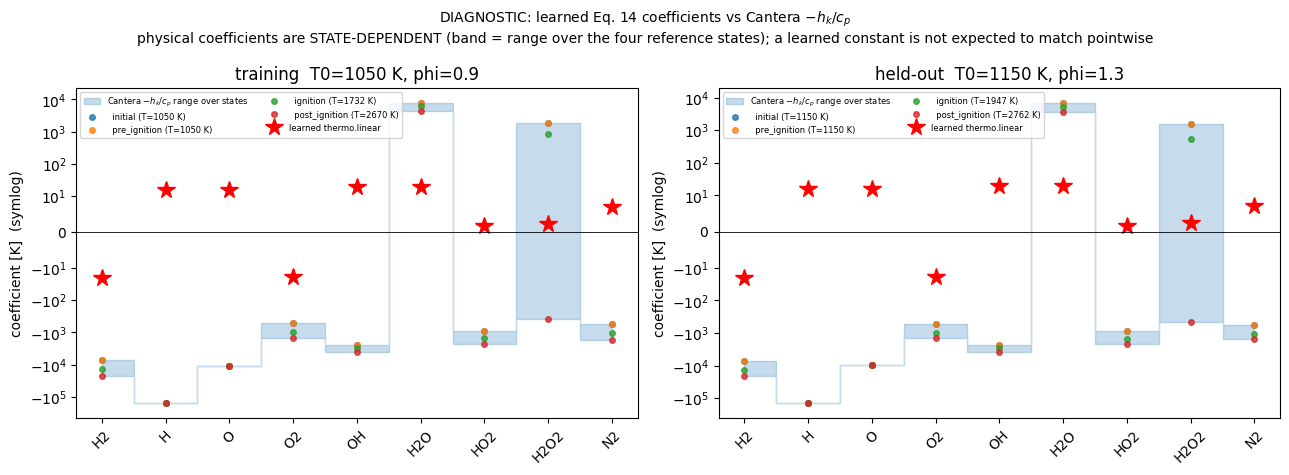

In [22]:
# Coefficient-scale figure. Magnitudes span orders of magnitude -> symlog scale.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    st = coef_store[(T0, phi)]
    x = np.arange(len(species))
    lo = np.minimum.reduce([i["coeffs"] for i in st.values()])
    hi = np.maximum.reduce([i["coeffs"] for i in st.values()])
    ax[c].fill_between(x, lo, hi, color="tab:blue", alpha=.25, step="mid",
                       label="Cantera $-h_k/c_p$ range over states")
    for name, info in st.items():
        ax[c].plot(x, info["coeffs"], "o", ms=4, alpha=.8, label=f"  {name} (T={info['T']:.0f} K)")
    ax[c].plot(x, learned, "r*", ms=13, label="learned thermo.linear")
    ax[c].set_yscale("symlog", linthresh=10)
    ax[c].set_xticks(x); ax[c].set_xticklabels(species, rotation=45)
    ax[c].axhline(0, color="k", lw=.6)
    ax[c].set_ylabel("coefficient [K]  (symlog)")
    ax[c].set_title(f"{role}  T0={T0} K, phi={phi}")
    ax[c].legend(fontsize=6, ncol=2)
fig.suptitle("DIAGNOSTIC: learned Eq. 14 coefficients vs Cantera $-h_k/c_p$\n"
             "physical coefficients are STATE-DEPENDENT (band = range over the four reference states); "
             "a learned constant is not expected to match pointwise", fontsize=10)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"hydrogen_DIAGNOSTIC_thermo_coefficients.{ext}", dpi=300,
                    bbox_inches="tight")
    print("saved", FIG_DIR / "hydrogen_DIAGNOSTIC_thermo_coefficients.pdf")
plt.show()

In [23]:
# Coefficient intervention: replace ONLY thermo.linear.weight, no retraining.
from hydrogen_thermo_intervention import (apply_thermo_coefficients, changed_parameters,
                                          evaluate_case)
rows = []
for T0, phi, role in DIAG_CONDS:
    ref = states[_cond_index(T0, phi)]
    base = evaluate_case(model, input_norm, solver, full_norm, t, ref)
    rows.append(dict(coefficients="baseline (as trained)", condition=f"{T0}/{phi}", role=role,
                     peak_T=round(base["peak_T"]), rise=round(base["T_rise"]),
                     ignites=base["ignites"], traj_MSE=round(base["trajectory_MSE"], 3),
                     T_MSE=round(base["temperature_MSE"], 2)))
    for name, info in coef_store[(T0, phi)].items():
        mi = apply_thermo_coefficients(model, info["coeffs"])
        assert changed_parameters(model, mi) == ["thermo.linear.weight"]   # provenance guard
        r = evaluate_case(mi, input_norm, solver, full_norm, t, ref)
        rows.append(dict(coefficients=f"Cantera @ {name}", condition=f"{T0}/{phi}", role=role,
                         peak_T=round(r["peak_T"]), rise=round(r["T_rise"]),
                         ignites=r["ignites"], traj_MSE=round(r["trajectory_MSE"], 3),
                         T_MSE=round(r["temperature_MSE"], 2)))
    rows.append(dict(coefficients="REFERENCE (Cantera truth)", condition=f"{T0}/{phi}", role=role,
                     peak_T=round(float(ref[:, -1].max())),
                     rise=round(float(ref[:, -1].max() - ref[0, -1])),
                     ignites=True, traj_MSE=0.0, T_MSE=0.0))
interv_df = pd.DataFrame(rows)
print(interv_df.to_string(index=False))
print("\nverified: only thermo.linear.weight was replaced; the trained model is untouched.")
interv_df

             coefficients condition     role  peak_T  rise  ignites  traj_MSE  T_MSE
    baseline (as trained)  1050/0.9 training    1059     9    False     2.867  25.49
        Cantera @ initial  1050/0.9 training    3239  2189     True     1.720   3.82
   Cantera @ pre_ignition  1050/0.9 training    3239  2189     True     1.720   3.82
       Cantera @ ignition  1050/0.9 training    3062  2012     True     1.274   1.78
  Cantera @ post_ignition  1050/0.9 training    2899  1849     True     0.930   0.59
REFERENCE (Cantera truth)  1050/0.9 training    2670  1620     True     0.000   0.00
    baseline (as trained)  1150/1.3 held-out    1160    10    False     3.146  29.79
        Cantera @ initial  1150/1.3 held-out    3136  1986     True     1.688   1.87
   Cantera @ pre_ignition  1150/1.3 held-out    3136  1986     True     1.688   1.87
       Cantera @ ignition  1150/1.3 held-out    2977  1827     True     1.330   0.69
  Cantera @ post_ignition  1150/1.3 held-out    2879  1729     Tr

,coefficients,condition,role,peak_T,rise,ignites,traj_MSE,T_MSE
0,baseline (as trained),1050/0.9,training,1059,9,False,2.867,25.49
1,Cantera @ initial,1050/0.9,training,3239,2189,True,1.720,3.82
2,Cantera @ pre_ignition,1050/0.9,training,3239,2189,True,1.720,3.82
3,Cantera @ ignition,1050/0.9,training,3062,2012,True,1.274,1.78
4,Cantera @ post_ignition,1050/0.9,training,2899,1849,True,0.930,0.59
5,REFERENCE (Cantera truth),1050/0.9,training,2670,1620,True,0.000,0.00
6,baseline (as trained),1150/1.3,held-out,1160,10,False,3.146,29.79
7,Cantera @ initial,1150/1.3,held-out,3136,1986,True,1.688,1.87
8,Cantera @ pre_ignition,1150/1.3,held-out,3136,1986,True,1.688,1.87
9,Cantera @ ignition,1150/1.3,held-out,2977,1827,True,1.330,0.69


### What this establishes - and what it does not

**ESTABLISHED**

- The completed H2 checkpoint **does not reproduce autoignition**.
- The failure is concentrated in **igniting conditions** and around the **ignition
  transition** (Figs. 8A/8B diagnostics; error is low during induction).
- The **thermodynamic `dT/dt` pathway is severely inadequate** in this checkpoint: the
  learned coefficients are O(10) where the physical `-h_k/cp` are O(10^2)-O(10^5) across
  every reference state, and several radical signs disagree.
- **Replacing only `thermo.linear` with physically scaled Cantera coefficients restores
  ignition-scale heating without any retraining** - and this holds for **all four**
  reference states (initial / pre-ignition / ignition / post-ignition), so the result is
  **not** an artifact of one arbitrary state choice.

**STRONGLY IMPLICATED**

- The learned thermodynamic linear pathway is a **major bottleneck** for this checkpoint.

**NOT YET ESTABLISHED** (do not claim these)

- that **random initialization is the root cause**;
- that the **FSA vs direct-autograd** difference is the root cause;
- that **loss normalization** is the root cause (the paper uses the same normalized loss
  and reports ignition);
- that **external input scaling** is the root cause;
- that the **kinetic core is completely correct**. The intervention is not a free win: the
  **temperature channel improves by 30-200x** (T-MSE 25.5 -> 0.12-0.76 training,
  29.8 -> 0.16-0.57 held-out), but the **total** trajectory MSE *rises* (2.81 -> 3.09-3.78),
  because the species were fitted against a flat thermal history and now see a hot one.
  Peak temperatures also overshoot the reference (2741-2970 K vs 2670/2762 K). So the
  intervention restores heat-release **scale**, not a corrected model - the peak `|dY/dt|`
  deficit from the earlier RHS diagnosis still stands.

**Next controlled experiment** (prepared, not run here): from the **same Stage-1 state**,
compare **random** vs **physics-seeded** Stage-2 `thermo.linear` initialization with
everything else identical - `--thermo-init random` vs `--thermo-init cantera`, results under
`results/reproduction/chemkan/hydrogen/diagnostics/`. Only that comparison can promote the
initialization hypothesis to a cause.

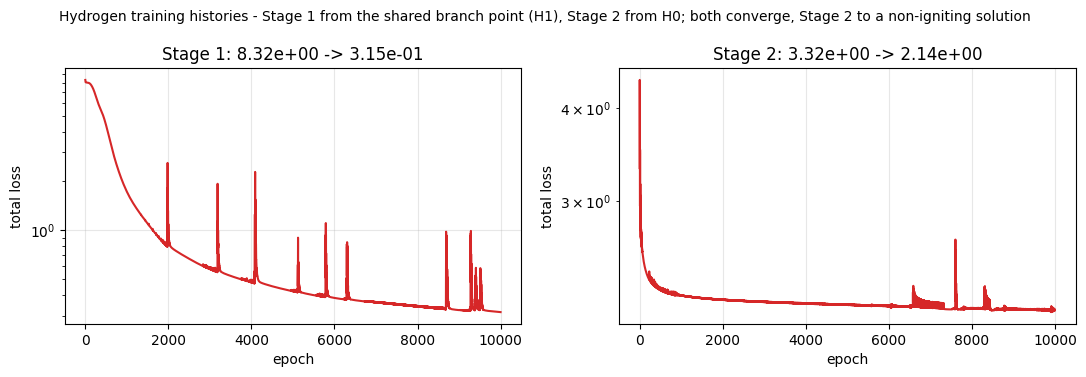

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for k, stage in enumerate((1, 2)):
    src = STAGE1_DIR if stage == 1 else RUN_DIR
    rows = list(csv.DictReader((src / f"history_stage{stage}.csv").open()))
    loss = [float(r["total_loss"]) for r in rows]
    ax[k].semilogy(loss, color="tab:red")
    ax[k].set_xlabel("epoch"); ax[k].set_ylabel("total loss"); ax[k].grid(alpha=.3)
    ax[k].set_title(f"Stage {stage}: {loss[0]:.2e} -> {loss[-1]:.2e}")
fig.suptitle("Hydrogen training histories - Stage 1 from the shared branch point (H1), "
             "Stage 2 from H0; both converge, Stage 2 to a non-igniting solution", fontsize=10)
fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIG_DIR / "hydrogen_training_histories.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
for k in npz.keys():
    print(k)

t
species
mechanism
state_layout
states
ics
is_test
train_states
test_states
train_ics
test_ics
u_min
u_max
ignition_delay
pressure
metadata


In [26]:
npz['train_states'][:,:,-1]

array([[ 950.        ,  949.99999985,  950.00000025, ...,  950.00020131,
         950.00020758,  950.00021392],
       [ 950.        ,  949.99999982,  950.00000032, ...,  950.00021121,
         950.00021769,  950.00022424],
       [ 950.        ,  949.99999979,  950.00000035, ...,  950.0002121 ,
         950.00021859,  950.00022515],
       ...,
       [1200.        , 1200.00075173, 1200.08481352, ..., 2780.95189745,
        2781.01589094, 2781.06953924],
       [1200.        , 1200.00072509, 1200.07519112, ..., 2780.1389448 ,
        2780.27484733, 2780.39184056],
       [1200.        , 1200.0006706 , 1200.06368691, ..., 2751.33027006,
        2751.59178425, 2751.82232044]])

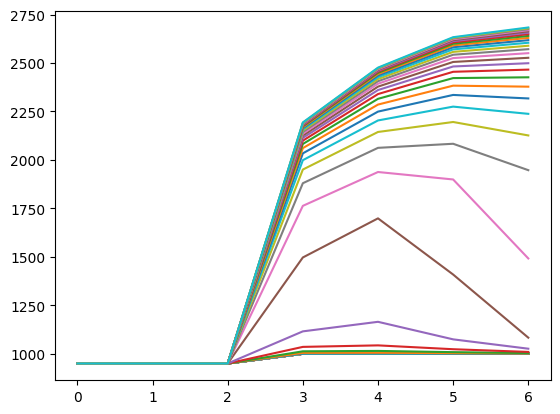

In [27]:
plt.plot(npz['train_states'][3:10,:,-1])

In [28]:
i = int(np.argmin(abs(ics[:,0]-1050) + abs(ics[:,1]-0.9)))
S = states[i]
dY_true = np.gradient(S[:, :-1], t, axis=0)          # true species rates
dT_true = np.gradient(S[:, -1], t)                   # true dT/dt

W = model.thermo.linear.weight.detach().numpy().ravel()
dT_from_linear = dY_true @ W                          # what Eq. 15 gives from TRUE rates

print("true dT/dt      peak: %.3e K/s" % dT_true.max())
print("linear(dY_true) peak: %.3e K/s" % dT_from_linear.max())
print("ratio          : %.3e" % (dT_from_linear.max()/dT_true.max()))

true dT/dt      peak: 3.528e+07 K/s
linear(dY_true) peak: 2.909e+05 K/s
ratio          : 8.244e-03


---

## Figures 7, 8A, 8B and Table I — from the saved checkpoints

No hydrogen retraining. Every number below is read from artifacts produced by the
evaluation scripts against completed checkpoints:

| artifact | produced by |
|---|---|
| `<run>/predictions/*_predictions.npz`, `metrics.json` | `evaluate_hydrogen.py` |
| `generalization/*_generalization_441.{csv,json,npz}` | `evaluate_hydrogen_grid.py` |
| `tables/hydrogen_ignition_delay_*.csv` | `evaluate_hydrogen_ignition.py` |
| `tables/hydrogen_inference_benchmark_*.json` | `benchmark/benchmark_inference.py` |

**`H0` is the primary reproduction and it fails.** `Hnorm1` is a separately labelled
initialization comparison that happens to do much better; that is one initialization, not
evidence of robustness across seeds, and it does not replace `H0`.

In [29]:
import json as _json
GEN = ROOT / "results/reproduction/chemkan/hydrogen/generalization"
SETS = {"H0 (primary, random init)": ("random_stage2_10000_seed0", RUN_DIR),
        "Hnorm1 (labelled init comparison)": ("normmatched_dir1_stage2_10000", COMPARE_DIR)}

for label, (stem, d) in SETS.items():
    m = _json.loads((d / "metrics.json").read_text())
    g = _json.loads((GEN / f"{stem}_generalization_441.json").read_text())
    print(f"{label}")
    print(f"   split MSE      : train {m['train_mse']:.4e}   test {m['test_mse']:.4e}")
    print(f"   441-grid MSE   : median {g['mse_median']:.4e}  max {g['mse_max']:.4e}  "
          f"failed {g['failed']}/{g['conditions']}")
    print(f"   grid provenance: {g['grid_provenance'][:78]}...")

H0 (primary, random init)
   split MSE      : train 2.1394e+00   test 3.1461e+00
   441-grid MSE   : median 2.6576e+00  max 3.2226e+00  failed 0/441
   grid provenance: RECONSTRUCTED 21x21: T0=linspace(950,1200,21), phi=linspace(0.5,1.5,21); count...
Hnorm1 (labelled init comparison)
   split MSE      : train 3.1010e-01   test 2.0879e-01
   441-grid MSE   : median 2.5355e-01  max 3.6916e+00  failed 0/441
   grid provenance: RECONSTRUCTED 21x21: T0=linspace(950,1200,21), phi=linspace(0.5,1.5,21); count...


### Figure 7 — trajectories at the two published conditions

Closed-loop integration from the initial state only: no reference temperature or species is
injected at later times. Left = a training condition (φ=0.9, T₀=1050 K), right = the
original held-out condition (φ=1.3, T₀=1150 K).

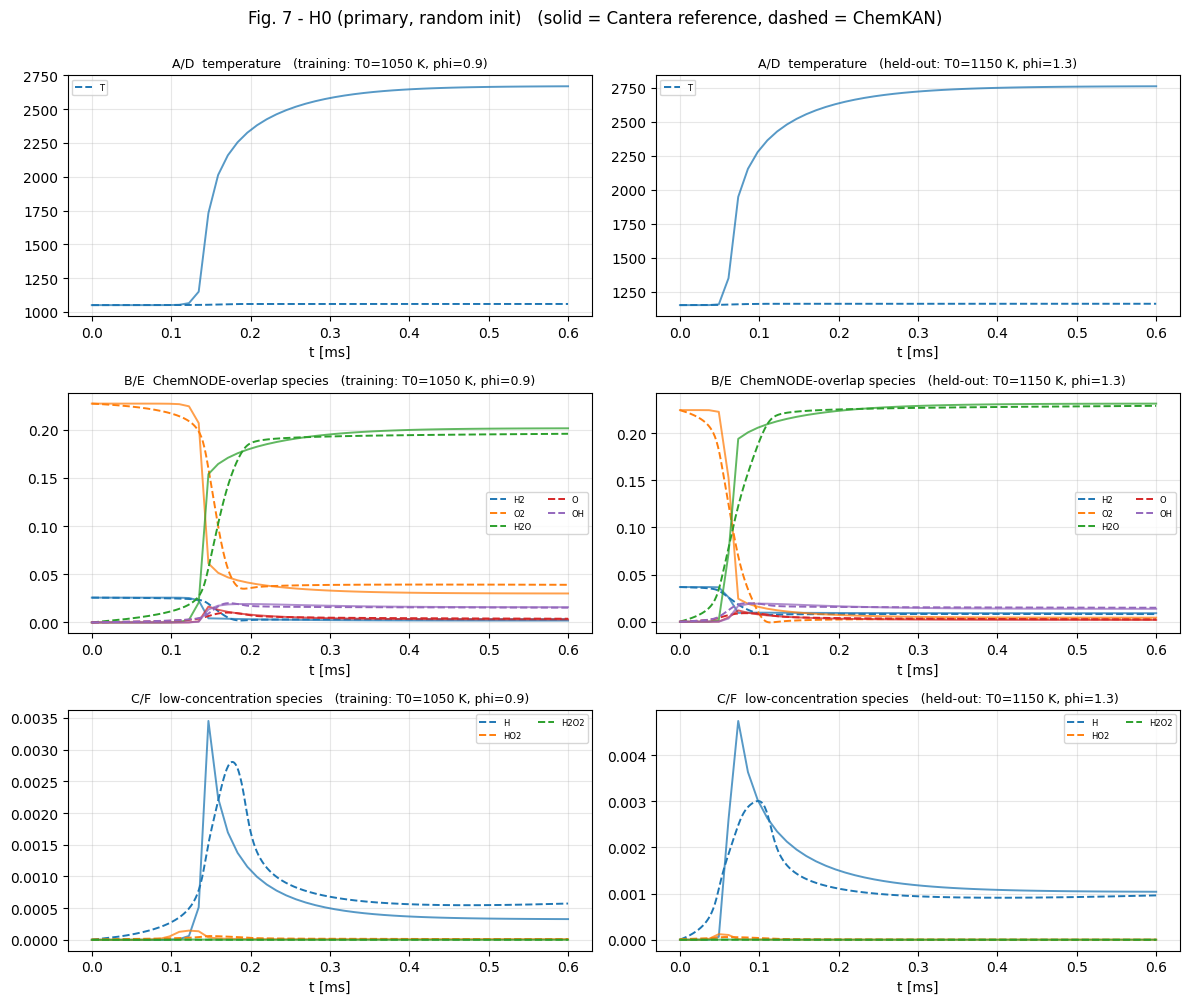

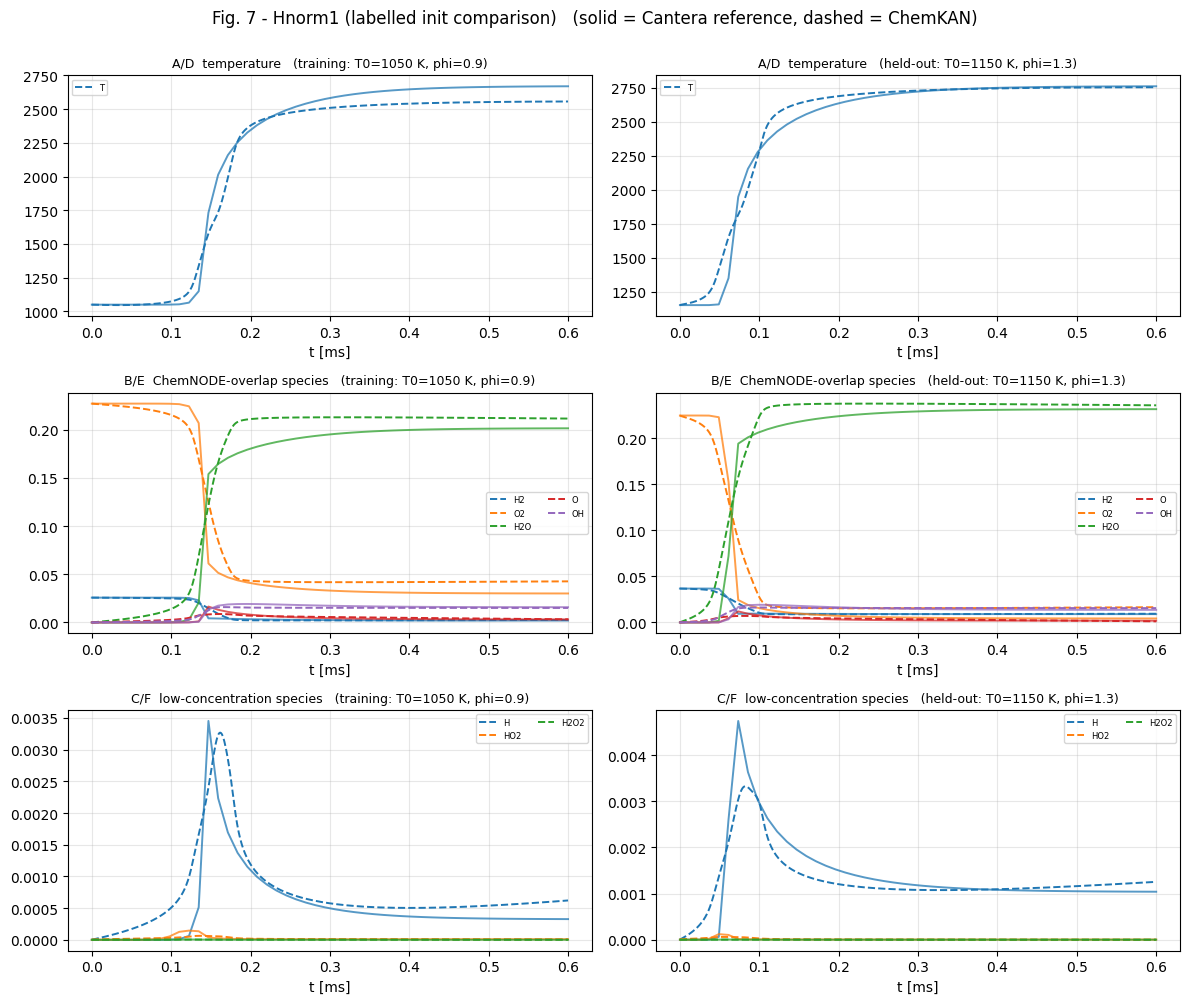

In [30]:
from chemkan.dynamics import ChemKANDynamics
from chemkan.solver import integrate

GROUPS = [("A/D  temperature", ["T"]),
          ("B/E  ChemNODE-overlap species", ["H2", "O2", "H2O", "O", "OH"]),
          ("C/F  low-concentration species", ["H", "HO2", "H2O2"])]
CONDS = [(1050.0, 0.9, "training"), (1150.0, 1.3, "held-out")]
t_d = np.linspace(float(t[0]), float(t[-1]), 601)

for label, (stem, d) in SETS.items():
    ck = torch.load(d / "checkpoint_final.pt", map_location="cpu", weights_only=False)
    mdl = build_chemkan(ck, len(species), "cpu")
    dyn = ChemKANDynamics(mdl, input_normalizer=load_input_scaling(ck, "cpu"))
    sol = solver_from_ckpt(ck)
    fig, axes = plt.subplots(3, 2, figsize=(12, 10))
    for c, (T0, phi, kind) in enumerate(CONDS):
        i = int(np.argmin(abs(ics[:, 0] - T0) + abs(ics[:, 1] - phi)))
        ref = states[i]
        with torch.no_grad():
            pr = integrate(dyn, torch.as_tensor(ref[0], dtype=torch.float32).unsqueeze(0),
                           torch.as_tensor(t_d, dtype=torch.float32), sol)[:, 0, :].numpy()
        for r, (title, names) in enumerate(GROUPS):
            ax = axes[r, c]
            for nm in names:
                k = len(species) if nm == "T" else species.index(nm)
                ax.plot(t * 1e3, ref[:, k], lw=1.4, alpha=.75)
                ax.plot(t_d * 1e3, pr[:, k], ls="--", lw=1.4,
                        color=ax.lines[-1].get_color(), label=nm)
            ax.set_title(f"{title}   ({kind}: T0={T0:.0f} K, phi={phi})", fontsize=9)
            ax.set_xlabel("t [ms]"); ax.legend(fontsize=6, ncol=2); ax.grid(alpha=.3)
    fig.suptitle(f"Fig. 7 - {label}   (solid = Cantera reference, dashed = ChemKAN)", y=1.0)
    fig.tight_layout()
    if SAVE_FIGURES:
        tag = "H0" if stem.startswith("random") else "Hnorm1"
        for _e in ("pdf", "png"):
            fig.savefig(FIG_DIR / f"fig07_hydrogen_trajectories_{tag}.{_e}", dpi=200,
                        bbox_inches="tight")
    plt.show()

### Figure 8A — 441-condition generalization

Same checkpoints, no retraining. The 21×21 grid (`T0 = linspace(950,1200,21)` ×
`phi = linspace(0.5,1.5,21)`) is RECONSTRUCTED from the paper's 441-condition count and
figure spacing. Normalization is the canonical train-only statistics — never refit on the
grid. Per-condition MSEs are plotted individually and never averaged beforehand.

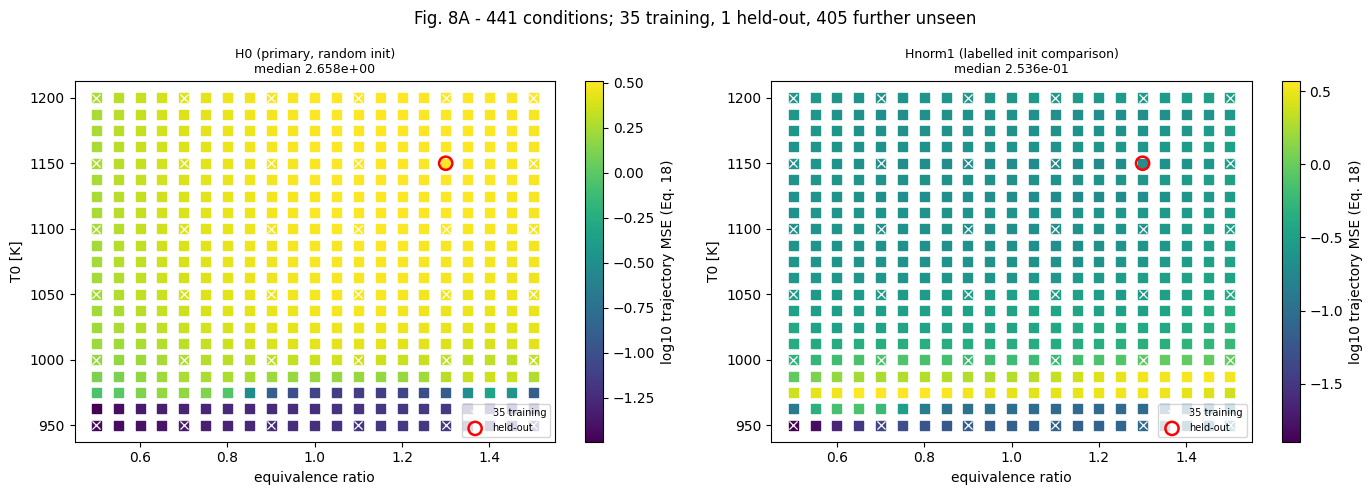

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, (stem, d)) in zip(axes, SETS.items()):
    rows = list(csv.DictReader(open(GEN / f"{stem}_generalization_441.csv")))
    T0 = np.array([float(r["T0_K"]) for r in rows]); ph = np.array([float(r["phi"]) for r in rows])
    mse = np.array([float(r["trajectory_mse"]) for r in rows])
    ok = np.array([r["status"] == "ok" for r in rows])
    tr = np.array([r["is_training"] == "True" for r in rows])
    ho = np.array([r["is_held_out"] == "True" for r in rows])
    s = ax.scatter(ph[ok], T0[ok], c=np.log10(mse[ok]), s=42, marker="s", cmap="viridis")
    ax.scatter(ph[tr], T0[tr], marker="x", s=34, c="white", lw=.9, label="35 training")
    ax.scatter(ph[ho], T0[ho], marker="o", s=90, facecolors="none", edgecolors="red",
               lw=1.8, label="held-out")
    if (~ok).any():
        ax.scatter(ph[~ok], T0[~ok], marker="X", s=60, c="red", label="failed")
    plt.colorbar(s, ax=ax, label="log10 trajectory MSE (Eq. 18)")
    ax.set_xlabel("equivalence ratio"); ax.set_ylabel("T0 [K]")
    ax.set_title(f"{label}\nmedian {np.median(mse[ok]):.3e}", fontsize=9)
    ax.legend(fontsize=7, loc="lower right")
fig.suptitle("Fig. 8A - 441 conditions; 35 training, 1 held-out, 405 further unseen")
fig.tight_layout()
if SAVE_FIGURES:
    for _e in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"fig08a_hydrogen_generalization_441.{_e}", dpi=200,
                    bbox_inches="tight")
plt.show()

### Figure 8B — ignition delay

Ignition delay = time of maximum dT/dt. Reference and model are put on the **same** dense
601-point grid over 0–0.6 ms and through the **same** estimator, so a coarse 50-point
reference derivative is never compared against a dense model derivative. The evaluated set
is fixed by which *reference* trajectories ignite — 30 of 36; the six 950 K cases do not
ignite in the window — never by whether the model succeeds.

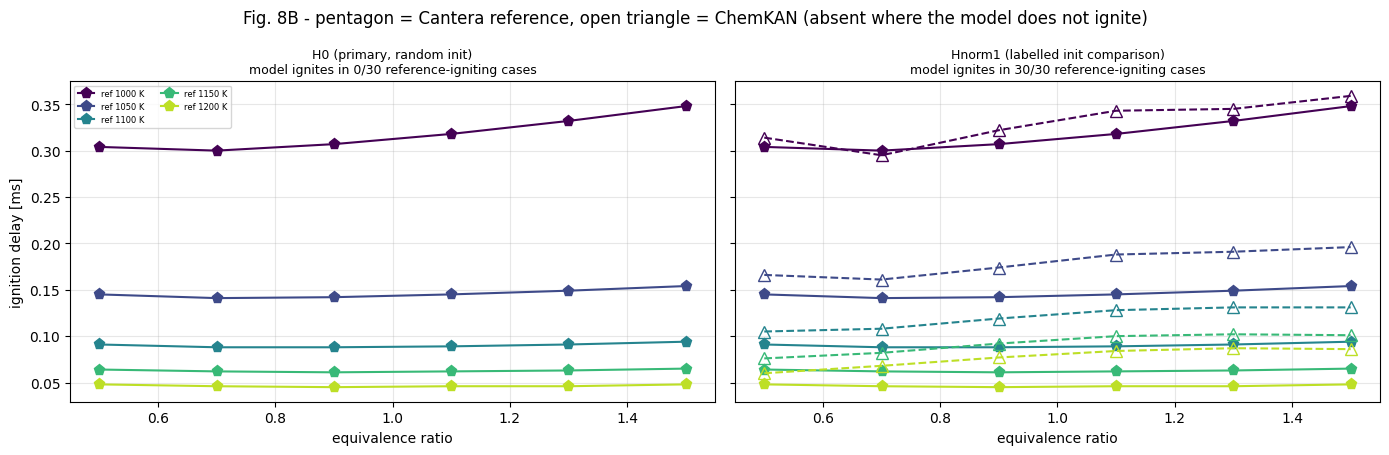

H0 (primary, random init): 30 reference-igniting conditions | statuses {'no_ignition_in_window': 30}
Hnorm1 (labelled init comparison): 30 reference-igniting conditions | statuses {'ignited': 30}
    |relative delay error|: median 28.9%  max 89.1%


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=True)
for ax, (label, (stem, d)) in zip(axes, SETS.items()):
    rows = list(csv.DictReader(open(TABLE_DIR / f"hydrogen_ignition_delay_{stem}.csv")))
    temps = sorted({float(r["T0_K"]) for r in rows})
    cmap = plt.cm.viridis(np.linspace(0, .9, len(temps)))
    n_ign = sum(1 for r in rows if r["status"].startswith("ignited"))
    for c, T0 in zip(cmap, temps):
        sel = [r for r in rows if float(r["T0_K"]) == T0]
        ax.plot([float(r["phi"]) for r in sel],
                [float(r["reference_delay_s"]) * 1e3 for r in sel],
                "p-", color=c, ms=8, label=f"ref {T0:.0f} K")
        got = [r for r in sel if r["chemkan_delay_s"]]
        if got:
            ax.plot([float(r["phi"]) for r in got],
                    [float(r["chemkan_delay_s"]) * 1e3 for r in got],
                    "^--", color=c, ms=8, mfc="none", label=f"ChemKAN {T0:.0f} K")
    ax.set_xlabel("equivalence ratio"); ax.grid(alpha=.3)
    ax.set_title(f"{label}\nmodel ignites in {n_ign}/{len(rows)} reference-igniting cases", fontsize=9)
axes[0].set_ylabel("ignition delay [ms]"); axes[0].legend(fontsize=6, ncol=2)
fig.suptitle("Fig. 8B - pentagon = Cantera reference, open triangle = ChemKAN "
             "(absent where the model does not ignite)")
fig.tight_layout()
if SAVE_FIGURES:
    for _e in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"fig08b_hydrogen_ignition_delay.{_e}", dpi=200,
                    bbox_inches="tight")
plt.show()

for label, (stem, d) in SETS.items():
    rows = list(csv.DictReader(open(TABLE_DIR / f"hydrogen_ignition_delay_{stem}.csv")))
    rel = [abs(float(r["relative_error"])) for r in rows if r["relative_error"]]
    st = {}
    for r in rows: st[r["status"]] = st.get(r["status"], 0) + 1
    print(f"{label}: {len(rows)} reference-igniting conditions | statuses {st}")
    if rel:
        print(f"    |relative delay error|: median {np.median(rel):.1%}  max {max(rel):.1%}")

### Table I — networks, parameters, species, and a *local* efficiency measurement

The paper's ChemNODE and ChemKAN speed-ups are literature values measured against
Arrhenius.jl on other hardware with an unstated timing scope. Our number is a **local
PyTorch-vs-Cantera benchmark** over the same task (36 initial conditions, 50 output times,
0–0.6 ms). The two are reported side by side and must not be merged.

Accuracy is reported *with* the timing, because a model that does not reproduce the
dynamics is fast for the wrong reason.

In [33]:
bench = {}
for label, (stem, d) in SETS.items():
    bench[label] = _json.loads(
        (TABLE_DIR / f"hydrogen_inference_benchmark_{stem}.json").read_text())

table = [
    dict(model="ChemNODE (Ref. 17)", networks=7, parameters=637,
         species="H2,O2,H2O,N2,O,OH + T", speedup="2.3x", source="paper_reported"),
    dict(model="ChemKAN (paper)", networks=1, parameters=344,
         species="9 species + T", speedup="2.0x", source="paper_reported"),
]
for label, b in bench.items():
    ok = next(r for r in b["cantera"]["runs"] if r.get("status") == "ok")
    acc = b["accuracy"]
    table.append(dict(
        model=f"ChemKAN ({label})", networks=1, parameters=b["parameter_count"],
        species=f"{len(species)} species + T",
        speedup=f"{ok['speedup_vs_chemkan']:.2f}x", source="local_measured"))
    print(f"{label}")
    print(f"   ChemKAN {b['chemkan']['median_s']:.3f} s vs Cantera {ok['median_s']:.3f} s "
          f"(rtol={ok['rtol']:g}, atol={ok['atol']:g})  ->  {ok['speedup_vs_chemkan']:.2f}x")
    print(f"   ignites in {acc['chemkan_igniting_within_reference_set']}/"
          f"{acc['reference_igniting_conditions']} reference-igniting conditions "
          f"(+{acc['chemkan_igniting_where_reference_does_not']} where the reference does not); "
          f"median peak-T error {acc['peak_temperature_abs_error_K']['median']:.1f} K")
    for r in b["cantera"]["runs"]:
        if r.get("status") != "ok":
            print(f"   Cantera at rtol={r['rtol']:g} atol={r['atol']:g}: {r['status']}")
    print(f"   hardware: {b['hardware']['machine']}, torch {b['chemkan']['torch']}, "
          f"{b['chemkan']['threads']} threads, {b['warmup']} warm-up + {b['repetitions']} reps")

if SAVE_TABLES:
    f = TABLE_DIR / "hydrogen_efficiency.csv"
    with f.open("w", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=list(table[0])); w.writeheader(); w.writerows(table)
    print("\nsaved", f)

H0 (primary, random init)
   ChemKAN 1.481 s vs Cantera 0.236 s (rtol=1e-09, atol=1e-15)  ->  0.16x
   ignites in 0/30 reference-igniting conditions (+0 where the reference does not); median peak-T error 1546.5 K
   Cantera at rtol=1e-06 atol=1e-08: integration_failed: CanteraError
   hardware: arm64, torch 2.13.0, 4 threads, 2 warm-up + 5 reps
Hnorm1 (labelled init comparison)
   ChemKAN 0.470 s vs Cantera 0.234 s (rtol=1e-09, atol=1e-15)  ->  0.50x
   ignites in 30/30 reference-igniting conditions (+2 where the reference does not); median peak-T error 38.1 K
   Cantera at rtol=1e-06 atol=1e-08: integration_failed: CanteraError
   hardware: arm64, torch 2.13.0, 4 threads, 2 warm-up + 5 reps

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/tables/hydrogen_efficiency.csv


**Table I outcome.** Both local measurements are **slower** than Cantera (0.16× for
`H0`, 0.50× for `Hnorm1`), not the paper's 2.0× speed-up. The comparison is not
like-for-like — different reference implementation, hardware and timing scope — so this
neither confirms nor refutes the paper's number; it is our own measurement, reported as
such. Cantera could not integrate at the model's own tolerances (rtol 1e-6, atol 1e-8) and
that is recorded per tolerance setting rather than hidden.

Note also that `H0` is *slower* than `Hnorm1` despite never igniting: a badly conditioned
right-hand side can force small solver steps without producing any physical ignition.

---

## Section III B — status against the paper

| paper result | our result | status | remaining difference |
|---|---|---|---|
| Fig. 7 temperature + species at both published conditions | `H0` produces no ignition at either condition; `Hnorm1` reproduces the rise | **not matched** (`H0`) | the primary run's Stage-2 solution is non-igniting |
| Fig. 8A 441-condition errors | all 441 evaluated per condition, 0 integration failures | **evaluated, not matched** | `H0` median MSE 2.66; `Hnorm1` 0.254 |
| Fig. 8A ≈10⁻⁴ at the 1000 K training conditions | our per-condition MSEs are order 10⁻¹–10⁰ | **not matched** | same absolute-error gap as biodiesel |
| Fig. 8B ignition delay over 30 conditions | `H0` ignites in **0/30**; `Hnorm1` in **30/30**, median delay error 28.9 % | **not matched** (`H0`), **partially matched** (`Hnorm1`) | `Hnorm1` also ignites in 2 conditions where the reference does not |
| Table I: 1 network, 344 parameters, 9 species + T | 1 network, 344 measured, 9 species + T | **matched** | — |
| Table I: 2.0× speed-up | 0.16× (`H0`), 0.50× (`Hnorm1`), local PyTorch-vs-Cantera | **not matched** | different reference implementation, hardware and timing scope |

**What this establishes.** The N=4/base-ON reading does not remove the Stage-2 ignition
failure. A single norm-matched initialization (`Hnorm1`) does recover ignition across all
30 reference-igniting conditions, which sharpens the evidence that the thermodynamic
pathway's initialization is strongly implicated — but it is **one** initialization, not a
seed study, and it does not establish a root cause. The detailed failure and initialization
diagnostics remain in Notebook 09; this notebook does not duplicate them.